## EDA

### Import Libraries

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict

### Load Data

In [94]:
# Load the dataset (replace 'your_dataset.csv' with the actual file path)
df = pd.read_csv('../data/processed/processed_dataset.csv')

# Define the directory path
directory_path = '../data/raw/train/'

# Load train raw data for app, sms, user, and voc using read_csv
data_og_app = pd.read_csv(f'{directory_path}train_app.csv')
data_og_sms = pd.read_csv(f'{directory_path}train_sms.csv')
data_og_user = pd.read_csv(f'{directory_path}train_user.csv')
data_og_voc = pd.read_csv(f'{directory_path}train_voc.csv')


### Overall Dataset Analysis

In [3]:
df

,phone_no_m,arpu_mean,arpu_var,arpu_max,arpu_min,arpu_median,arpu_sum,arpu_skew,arpu_sem,arpu_quantile,...,sms_day_mode_count,sms_day_nunique,sms_dayname_mode,sms_dayname_mode_count,sms_dayname_nunique,sms_rate,sms_contacts_proportion,sms_calltype1_count,sms_calltype2_count,sms_calltype2_proportion
0,672ddbf02a5544d32e4ecc9433b1981bffe23bf912273a...,45.13250,0.140450,46.06,45.00,45.000,361.06,2.828427,0.132500,45.000,...,93.0,31.0,Friday,229.0,7.0,6.710900,0.149011,6.0,1410.0,0.995763
1,5e1272273e041e82cb275ae877710be98cdaf5b0a8f34d...,63.93750,337.148393,79.30,34.10,69.500,511.50,-0.740958,6.491806,69.500,...,356.0,31.0,Tuesday,659.0,7.0,11.653846,0.085809,25.0,4217.0,0.994107
2,eaab3472ec87b076e69e6e8bb62b14341638fc63661a6c...,31.78125,353.889241,63.00,18.85,22.075,254.25,1.414106,6.651027,22.075,...,67.0,31.0,Tuesday,262.0,7.0,3.777473,0.264727,97.0,1278.0,0.929455
3,0ce1bb415704178bf44e9c9b431a39b083a132c8e6d99f...,54.07125,3779.156612,173.12,19.00,21.200,432.57,1.570987,21.734640,21.200,...,178.0,31.0,Thursday,785.0,7.0,3.715986,0.269108,48.0,4322.0,0.989016
4,28b87f35f63f65096a53e3a4c97eaffd4a6c43ffa7e92d...,50.00000,0.000000,50.00,50.00,50.000,400.00,0.000000,0.000000,50.000,...,65.0,31.0,Thursday,120.0,7.0,10.478261,0.095436,1.0,722.0,0.998617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6101,bfc115bb229849f256e52e45cac5c400125cfe24c443f1...,1.83750,0.185536,2.50,1.30,1.800,14.70,0.515935,0.152289,1.800,...,92.0,31.0,Monday,236.0,7.0,6.565217,0.152318,71.0,1288.0,0.947756
6102,081f09756ed35d349558170213175ceb91b8d1a0392d1d...,307.76000,410344.235800,1453.50,5.24,22.000,1538.80,2.234443,286.476608,22.000,...,14719.0,10.0,Sunday,14715.0,6.0,1.041825,0.959854,14368.0,403.0,0.027283
6103,fbf1d2b9437078cc8b573528034557f7165cc8ce8776de...,83.14000,NaN,83.14,83.14,83.140,83.14,NaN,NaN,83.140,...,10.0,3.0,Monday,10.0,3.0,3.000000,0.333333,0.0,21.0,1.000000
6104,aee363f2f1ff659167a2566d7b466fefd27c907a469590...,254.39375,148.393427,272.60,243.00,252.195,2035.15,0.515840,4.306876,252.195,...,114.0,31.0,Tuesday,361.0,7.0,8.445312,0.118409,11.0,2151.0,0.994912


In [3]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Adjust width to fit screen
pd.set_option('display.expand_frame_repr', False)  # Prevent wrapping

In [5]:
print("\nData Types:\n", df.dtypes)


Data Types:
 phone_no_m                           object
arpu_mean                           float64
arpu_var                            float64
arpu_max                            float64
arpu_min                            float64
arpu_median                         float64
arpu_sum                            float64
arpu_skew                           float64
arpu_sem                            float64
arpu_quantile                       float64
idcard_cnt                            int64
label                                 int64
app_usage_count                       int64
flow_mean                           float64
flow_median                         float64
flow_min                            float64
flow_max                            float64
flow_var                            float64
flow_sum                            float64
months_count                          int64
flow_month                          float64
imei_count                          float64
imei_list         

In [ ]:
# select all numeric columns (exclude label and phone number)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['label'])

# summary statistics for all numerical features
summary_stats = df[numerical_cols].describe().transpose()
print("Summary Statistics:\n", summary_stats)

Summary Statistics:
                                    count           mean            std        min          25%          50%           75%           max
arpu_mean                         5932.0      66.516913      90.252369 -13.780000    18.231563    43.186250     85.256250  2.406660e+03
arpu_var                          5470.0   14593.390076  398944.713867   0.000000     0.873970    39.696578    385.674854  2.786160e+07
arpu_max                          5932.0     103.022328     233.166947 -13.780000    23.760000    59.000000    118.700000  1.184860e+04
arpu_min                          5932.0      47.890438      67.534046 -54.740000     9.000000    22.000000     68.027500  1.136380e+03
arpu_median                       5932.0      59.989888      78.956052 -13.780000    16.282500    37.087500     75.897500  1.317370e+03
arpu_sum                          6106.0     401.970601     481.293898 -25.080000    85.087500   217.400000    575.490000  1.203330e+04
arpu_skew                  

In [7]:
print("\nMissing Values:\n", df.isnull().sum().sort_values(ascending=False))


Missing Values:
 arpu_skew                           914
flow_var                            873
arpu_var                            636
arpu_sem                            636
arpu_max                            174
arpu_min                            174
arpu_median                         174
arpu_quantile                       174
arpu_mean                           174
call_outgoing_county_unique         117
call_outgoing_city_unique           117
voc_hour_mode_count                  81
voc_day_mode                         81
voc_date_unique                      81
voc_day_mode_count                   81
voc_hour_mode                        81
voc_hour_unique                      81
voc_dayname_mode_count               81
call_dur_max                         81
voc_dayname_mode                     81
voccalltype3_count                   81
voc_dayname_unique                   81
calltypeid_unique                    81
voc_calltype1_count                  81
voc_calltype2_count   

In [8]:
# Number of subscribers
print("Number of subscribers:", len(df["phone_no_m"].unique()))

# Check that each subscriber is unique (no duplicates)
print("Subscribers are unique:", df['phone_no_m'].duplicated().sum() == 0)

Number of subscribers: 6106
Subscribers are unique: True


/var/folders/rh/zzd0r4d138qcmkk4wydl6k600000gn/T/ipykernel_46428/1759663874.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette={'0': 'skyblue', '1': 'salmon'})
/var/folders/rh/zzd0r4d138qcmkk4wydl6k600000gn/T/ipykernel_46428/1759663874.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Fraud', 'Fraud'])


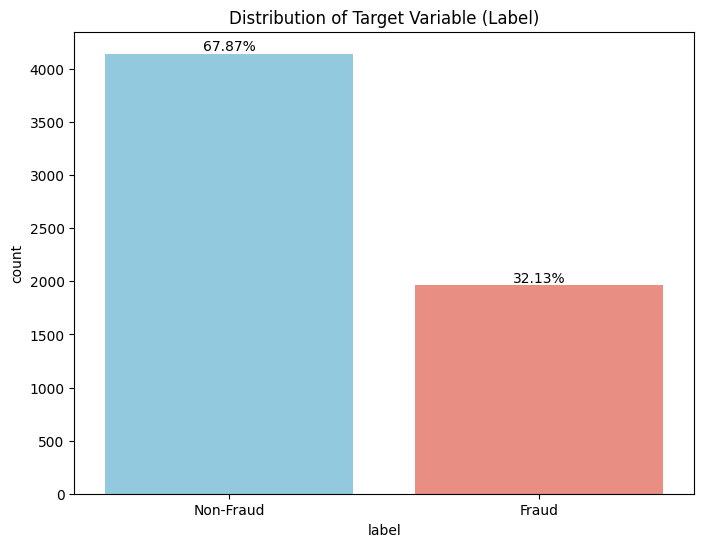

In [9]:
# Target Variable Analysis
# Distribution of the target variable with percentages
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='label', data=df, palette={'0': 'skyblue', '1': 'salmon'})
plt.title('Distribution of Target Variable (Label)')
ax.set_xticklabels(['Non-Fraud', 'Fraud'])

# Add percentages on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()

The dataset is not severely imbalanced. Train models on this dataset and evaluate performance for both classes. If fraud detection (minority class) performs poorly, consider oversampling the minority class.

False negatives (misclassifying fraud) are more costly than false positives (flagging non-fraud as fraud).

In [91]:
# Features that are highly correlated to each other

correlation_matrix = df.corr(numeric_only=True)
correlations = correlation_matrix.abs().unstack()

# Remove self-correlations (feature with itself)
correlations = correlations[correlations.index.get_level_values(0) != correlations.index.get_level_values(1)]

# Drop duplicate pairs (e.g., (A, B) and (B, A))
correlations = correlations.groupby([frozenset(i) for i in correlations.index]).first()

# Filter high correlations
high_corr = correlations[correlations > 0.9].sort_values(ascending=False)
print(high_corr)

(arpu_quantile, arpu_median)                         1.000000
(call_count, voc_dayname_mode_count)                 0.984299
(sms_day_mode_count, sms_dayname_mode_count)         0.980084
(flow_month, flow_sum)                               0.972392
(call_outgoing_county_unique, call_county_unique)    0.967204
(sms_nunique_contact, sms_dayname_mode_count)        0.959552
(voc_hour_mode_count, call_count)                    0.955191
(voc_hour_mode_count, voc_dayname_mode_count)        0.954492
(sms_day_mode_count, sms_nunique_contact)            0.953830
(call_city_unique, call_outgoing_city_unique)        0.948864
(voc_calltype1_count, voc_hour_mode_count)           0.931586
(voc_calltype1_count, voc_dayname_mode_count)        0.921206
(voc_calltype1_count, call_count)                    0.916332
(flow_month, flow_mean)                              0.907293
dtype: float64


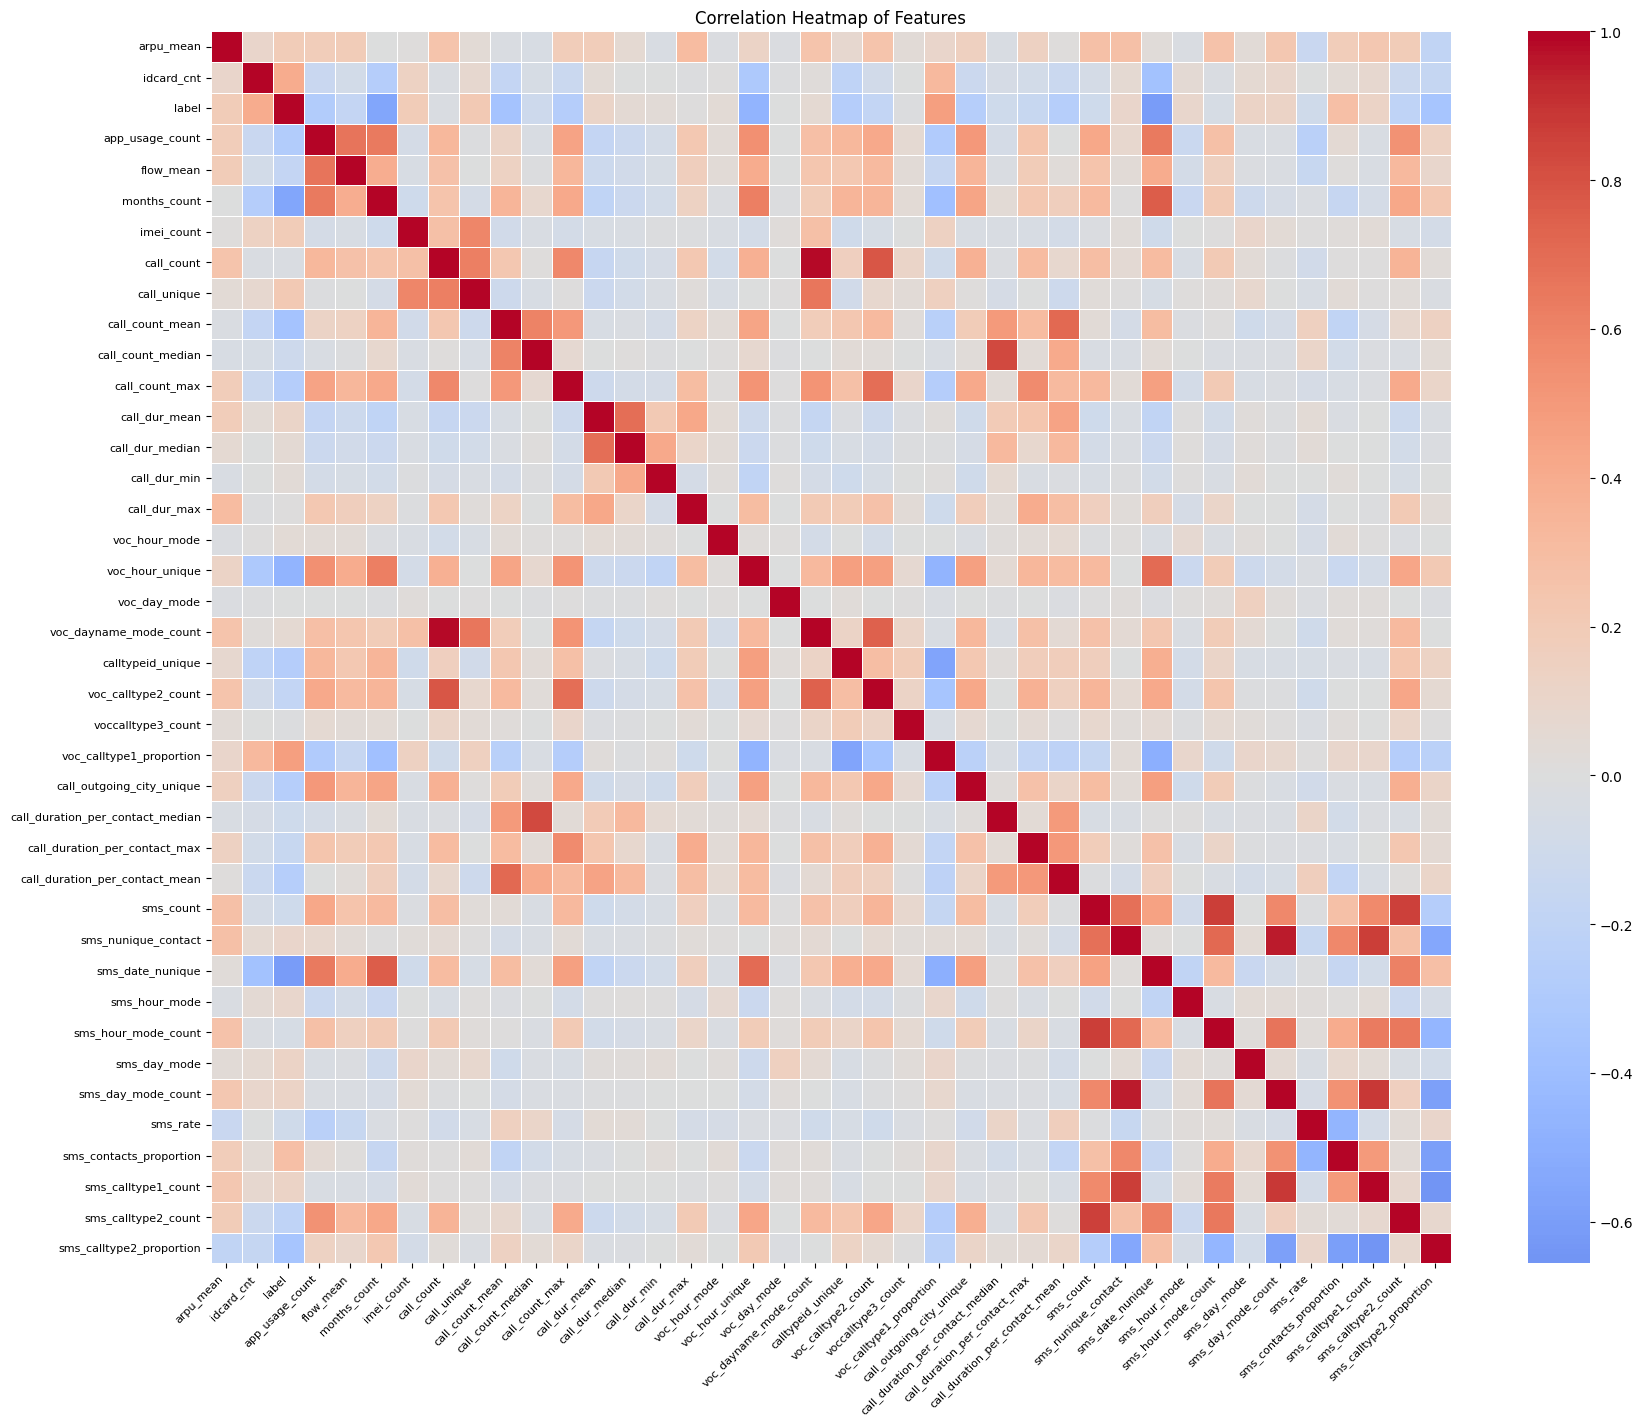

In [ ]:
## Correlation heatmap between variables

# drop non-numeric variables
df_numeric = df.select_dtypes(include=['int64', 'float64']) # drops phone_no_m, imei_list, voc_dayname_mode, sms_dayname_mode

# drop columns that are highly related to another column
flow_cols = [ # keep flow_mean
    'flow_median', 'flow_min', 'flow_max', 
    'flow_var', 'flow_sum', 'flow_month'
]
arpu_cols = [ # keep arpu_mean
    'arpu_var', 'arpu_max', 'arpu_min', 
    'arpu_median', 'arpu_sum', 'arpu_skew', 
    'arpu_sem'
]
call_cols = [ # keep call_outgoing_city_unique
    'call_county_unique',
    'call_city_unique',
    'call_outgoing_county_unique'
]
voc_cols = [ 
    'voc_hour_mode_count', # keep call_count
    'voc_day_mode_count', # keep call_count
    'voc_calltype1_count', # keep call_count
    'voc_date_unique', # keep voc_hour_unique
    'voc_dayname_unique' # keep voc_hour_unique
]
sms_cols = [
    'sms_dayname_mode_count', #sms_day_mode_count
    'sms_hour_nunique', # keep sms_date_nunique
    'sms_day_nunique', # keep sms_date_nunique
    'sms_dayname_nunique' # keep sms_date_nunique
]

cols_to_drop = flow_cols + arpu_cols + call_cols + voc_cols + sms_cols
df_filtered = df_numeric.drop(columns=cols_to_drop)

# compute the correlation matrix
corr_matrix = df_filtered.corr() 

# plot heatmap
plt.figure(figsize=(20, 16)) 
sns.heatmap(
    corr_matrix,              
    cmap='coolwarm',          # color scheme (alternatives: 'viridis', 'plasma')
    center=0,                 # where to center the colormap
    annot=False,              # shows correlation coefficient values
    fmt=".2f",                # format for annot values
    linewidths=0.5            # space between cells
)

plt.xticks(rotation=45, ha='right', fontsize=8)  
plt.yticks(rotation=0, fontsize=8)               

plt.title('Correlation Heatmap of Features') 
plt.show()

In [11]:
# Features with high positive or negative correlations with the label might be strong fraud indicators?

# Correlation of all features with the label
corr_with_label = df_filtered.corr()['label'].sort_values(ascending=False)
print(corr_with_label, "\n")

top_corr_condition = (corr_with_label > 0.3) | (corr_with_label < -0.3)
print(top_corr_condition) # if True, more correlated with label -> potentially stronger fraud indicators
# e.g. amount of incoming calls, days that the call occurs, number of call interactions with other phones

label                               1.000000
voc_calltype1_proportion            0.472528
idcard_cnt                          0.400548
sms_contacts_proportion             0.282211
call_unique                         0.214962
arpu_mean                           0.194022
imei_count                          0.188308
sms_calltype1_count                 0.126570
sms_day_mode                        0.126441
sms_day_mode_count                  0.123087
call_dur_mean                       0.118648
sms_nunique_contact                 0.098336
sms_hour_mode                       0.092968
voc_dayname_mode_count              0.056953
call_dur_median                     0.053153
voc_hour_mode                       0.043253
call_dur_min                        0.035480
call_dur_max                        0.007322
voc_day_mode                       -0.004789
voccalltype3_count                 -0.011997
call_count                         -0.024704
sms_hour_mode_count                -0.049745
sms_rate  

#### Features with High Correlation to the Target Variable (Label)

Features with strong positive or negative correlations to the target variable (`label`) may serve as significant indicators of fraudulent behavior. Below is a detailed analysis of such features:

- **voc_calltype1_proportion**: Proportion of outgoing calls.
- **voc_day_mode_count**: Frequency of calls on the most active day.
- **sms_calltype2_proportion**: Proportion of incoming SMS.
- **call_count_mean**: Mean number of unique numbers called.
- **voc_hour_nunique**: Number of unique hours during which calls were made.
- **sms_hour_nunique**: Number of unique hours during which SMS were sent.
- **months_count**: Month identifiers (may be influenced by the lack of data).
- **voc_date_unique**: Number of unique days with calls. Alternatively, analyzing `voc_day_mode` could provide insights into the most frequent day for calls.
- **sms_day_nunique**: Number of unique days with SMS activity.

#### Notes:
- Features such as `voc_day_mode_count` and `voc_hour_nunique` highlight temporal patterns in user behavior, which could be indicative of fraudulent activity.
- The inclusion of `voc_calltype1_proportion` and `call_count_mean` suggests that communication patterns (e.g., call and SMS proportions) are critical in distinguishing between fraudulent and non-fraudulent behavior.
- While `months_count` is included, its significance may be limited due to potential biases introduced by incomplete data.

### Old Dataset Analysis

In [29]:
fraud_numbers = df[df['label'] == 1]['phone_no_m']
non_fraud_numbers = df[df['label'] == 0]['phone_no_m']

fraud_data_app = data_og_app[data_og_app['phone_no_m'].isin(fraud_numbers)]
non_fraud_data_app = data_og_app[data_og_app['phone_no_m'].isin(non_fraud_numbers)]

fraud_data_sms = data_og_sms[data_og_sms['phone_no_m'].isin(fraud_numbers)]
non_fraud_data_sms = data_og_sms[data_og_sms['phone_no_m'].isin(non_fraud_numbers)]

fraud_data_voc = data_og_voc[data_og_voc['phone_no_m'].isin(fraud_numbers)]
non_fraud_data_voc = data_og_voc[data_og_voc['phone_no_m'].isin(non_fraud_numbers)]

fraud_data_user = data_og_user[data_og_user['phone_no_m'].isin(fraud_numbers)]
non_fraud_data_user = data_og_user[data_og_user['phone_no_m'].isin(non_fraud_numbers)]

In [13]:
len_sets_ns = non_fraud_data_voc.groupby('imei_m')['phone_no_m'].nunique()
len_sets_s = fraud_data_voc.groupby('imei_m')['phone_no_m'].nunique()

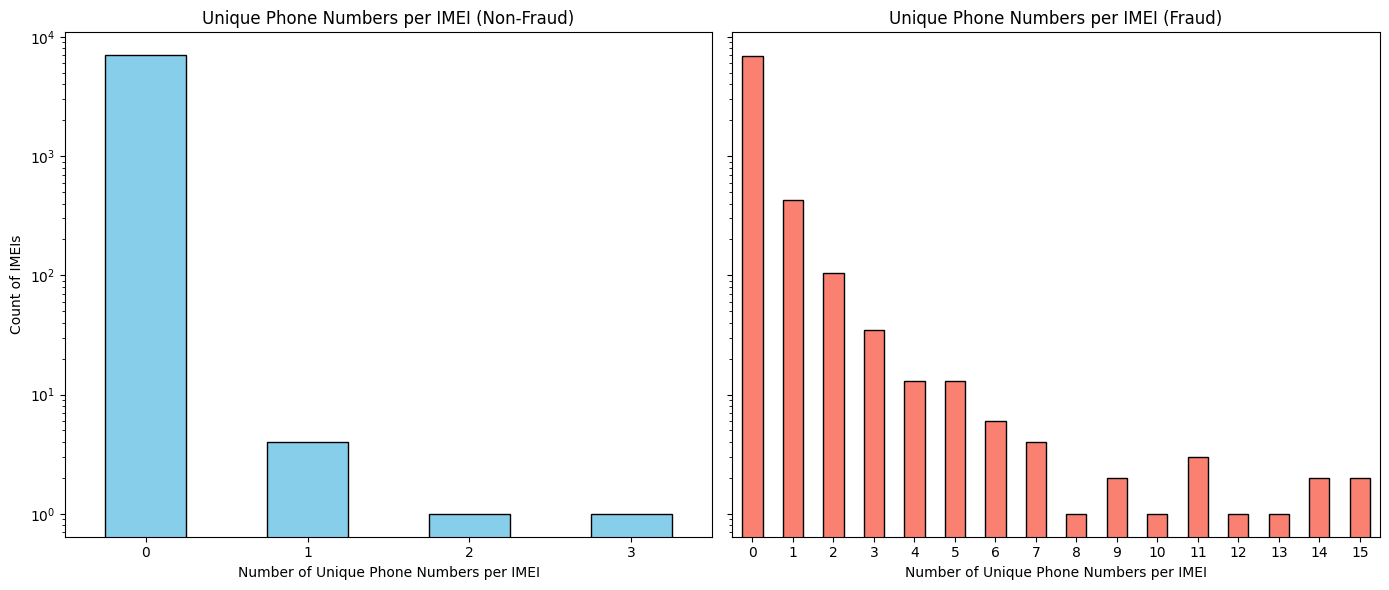

In [14]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for Non-fraud Data
len_sets_ns.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title("Unique Phone Numbers per IMEI (Non-Fraud)")
axes[0].set_xlabel("Number of Unique Phone Numbers per IMEI")
axes[0].set_ylabel("Count of IMEIs")
axes[0].set_yscale('log')
axes[0].set_xticklabels(axes[0].get_xticks(), rotation=0)

# Plot for fraud Data
len_sets_s.value_counts().sort_index().plot(kind='bar', color='salmon', edgecolor='black', ax=axes[1])
axes[1].set_title("Unique Phone Numbers per IMEI (Fraud)")
axes[1].set_xlabel("Number of Unique Phone Numbers per IMEI")
axes[1].set_yscale('log')
axes[1].set_xticklabels(axes[1].get_xticks(), rotation=0)

# Adjust layout for better visibility
plt.tight_layout()
plt.show()

Non-fraud numbers typically do not associate with many unique numbers on the same IMEI (device).

In [15]:
# Group fraud data by 'city_name' and count unique phone numbers ('phone_no_m') in each city
fraud_counts = fraud_data_voc.groupby('city_name')['phone_no_m'].nunique()

# Group the entire dataset by 'city_name' and count unique phone numbers ('phone_no_m') in each city
total_counts = data_og_voc.groupby('city_name')['phone_no_m'].nunique()

# Calculate the proportion of fraud phone numbers in each city
fraud_proportion = fraud_counts / total_counts

# Display the fraud proportion for each city
print(fraud_proportion)

# Observation: The fraud proportion does not clearly indicate that any specific city has a significantly higher number of fraudsters

city_name
乐山     0.211066
内江     0.174014
凉山     0.129870
南充     0.172816
宜宾     0.197832
巴中     0.176136
广元     0.166113
广安     0.201058
德阳     0.196311
成都     0.282841
攀枝花    0.115152
泸州     0.182965
甘孜     0.107843
眉山     0.152905
绵阳     0.170765
自贡     0.120283
资阳     0.154688
达州     0.201044
遂宁     0.181818
阿坝     0.134715
雅安     0.108235
Name: phone_no_m, dtype: float64


#### Call Type observations

In [ ]:
# Group by phone_no_m and calltype_id, then count occurrences of each calltype
grouped_data = fraud_data_voc.groupby(['phone_no_m', 'calltype_id']).size().unstack(fill_value=0)

# Compute differences and sums
grouped_data['Diff btwn Outgoing and Incoming Calls'] = grouped_data[1] - grouped_data[2]

In [ ]:
grouped_data = data_og_voc.groupby(['phone_no_m', 'calltype_id']).size().unstack(fill_value=0)
call_type_2_counts = grouped_data[2]

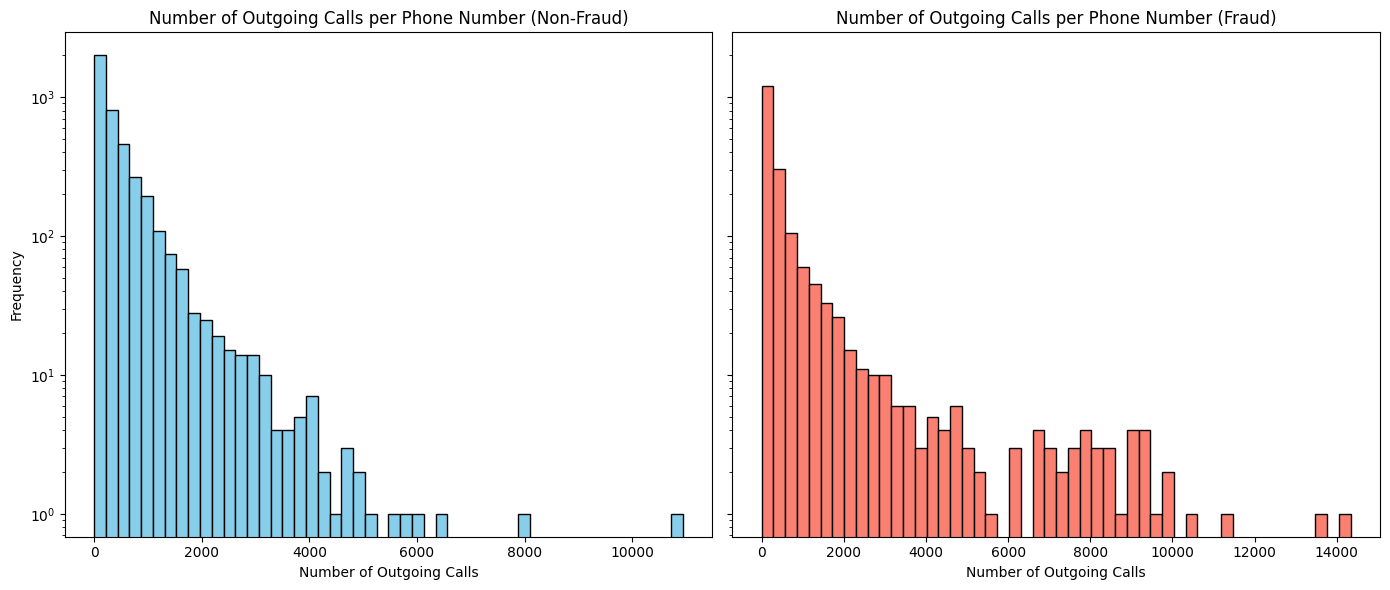

In [18]:
# Extract the count of call type 1 for non-fraud and fraud data
non_fraud_call_type_1_counts = non_fraud_data_voc.groupby('phone_no_m')['calltype_id'].apply(lambda x: (x == 1).sum())
fraud_call_type_1_counts = fraud_data_voc.groupby('phone_no_m')['calltype_id'].apply(lambda x: (x == 1).sum())

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_call_type_1_counts, bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Number of Outgoing Calls per Phone Number (Non-Fraud)')
axes[0].set_xlabel('Number of Outgoing Calls')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Plot histogram for fraud data
axes[1].hist(fraud_call_type_1_counts, bins=50, edgecolor='black', color='salmon')
axes[1].set_title('Number of Outgoing Calls per Phone Number (Fraud)')
axes[1].set_xlabel('Number of Outgoing Calls')
axes[1].set_yscale('log')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


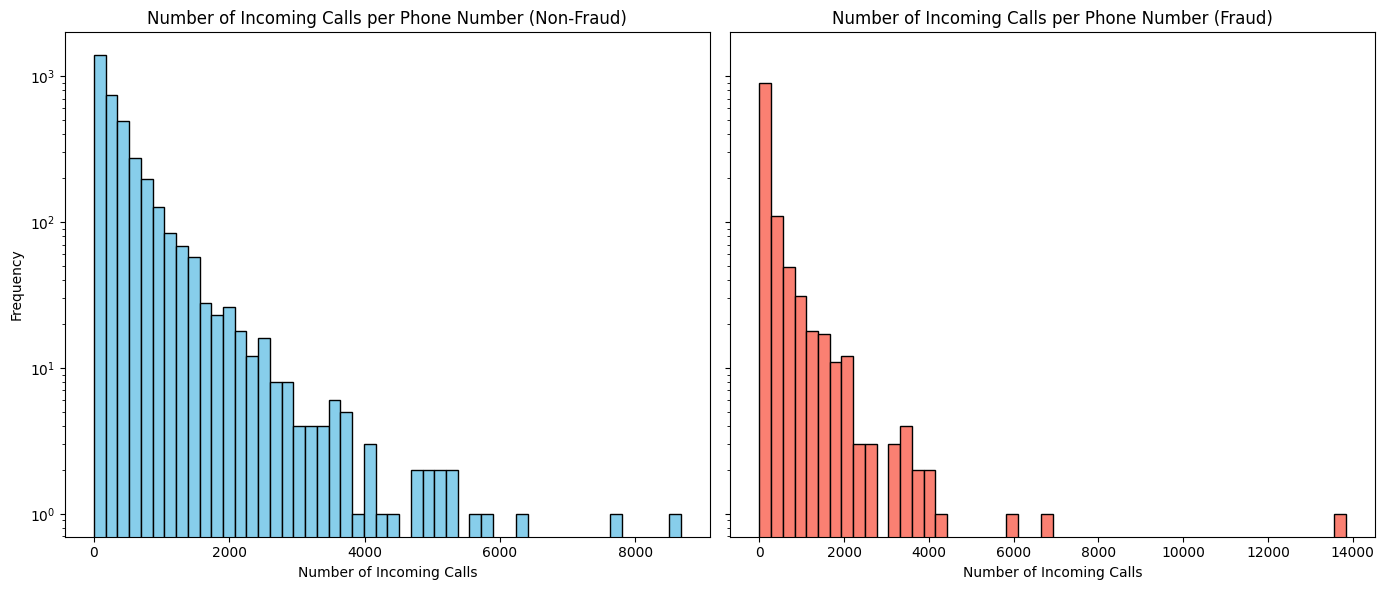

In [19]:
# Non-Fraud data
non_fraud_call_type_2_counts = non_fraud_data_voc[non_fraud_data_voc['calltype_id'] == 2].groupby('phone_no_m').size()

# Fraud data
fraud_call_type_2_counts = fraud_data_voc[fraud_data_voc['calltype_id'] == 2].groupby('phone_no_m').size()

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_call_type_2_counts, bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Number of Incoming Calls per Phone Number (Non-Fraud)')
axes[0].set_xlabel('Number of Incoming Calls')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Plot histogram for fraud data
axes[1].hist(fraud_call_type_2_counts, bins=50, edgecolor='black', color='salmon')
axes[1].set_title('Number of Incoming Calls per Phone Number (Fraud)')
axes[1].set_xlabel('Number of Incoming Calls')
axes[1].set_yscale('log')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


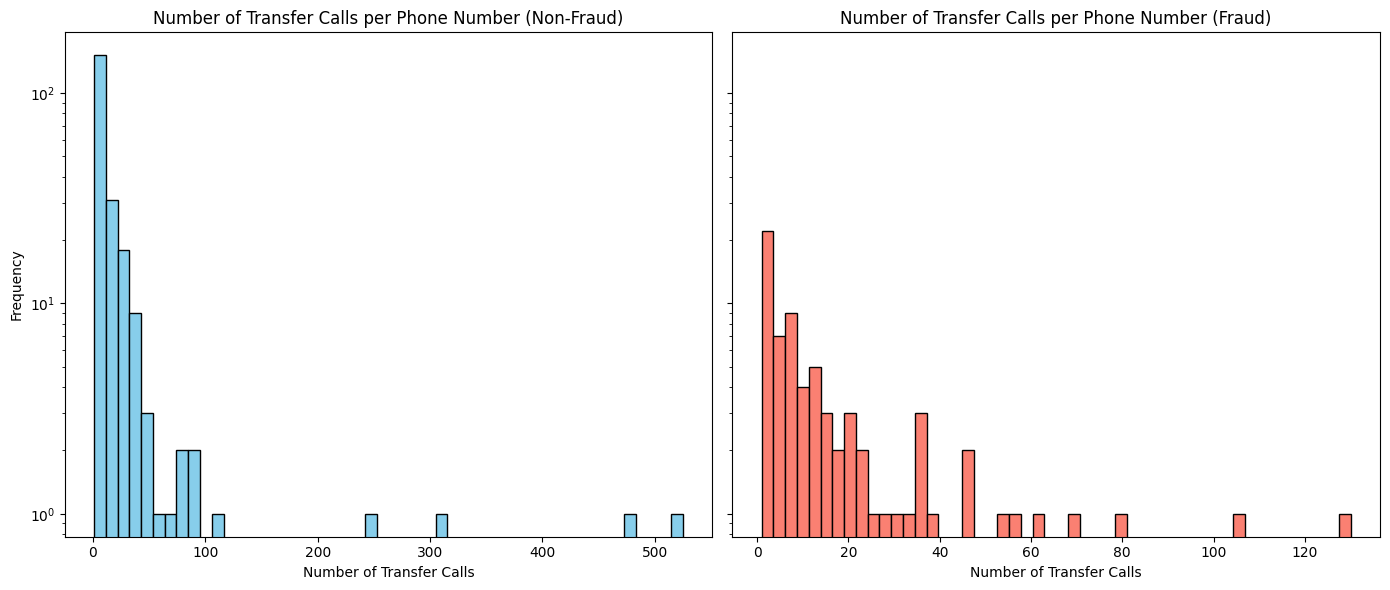

In [20]:
# Extract the count of call type 3 for non-fraud and fraud data
non_fraud_call_type_3_counts = non_fraud_data_voc[non_fraud_data_voc['calltype_id'] == 3].groupby('phone_no_m').size()
fraud_call_type_3_counts = fraud_data_voc[fraud_data_voc['calltype_id'] == 3].groupby('phone_no_m').size()

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_call_type_3_counts, bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Number of Transfer Calls per Phone Number (Non-Fraud)')
axes[0].set_xlabel('Number of Transfer Calls')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Plot histogram for fraud data
axes[1].hist(fraud_call_type_3_counts, bins=50, edgecolor='black', color='salmon')
axes[1].set_title('Number of Transfer Calls per Phone Number (Fraud)')
axes[1].set_xlabel('Number of Transfer Calls')
axes[1].set_yscale('log')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()

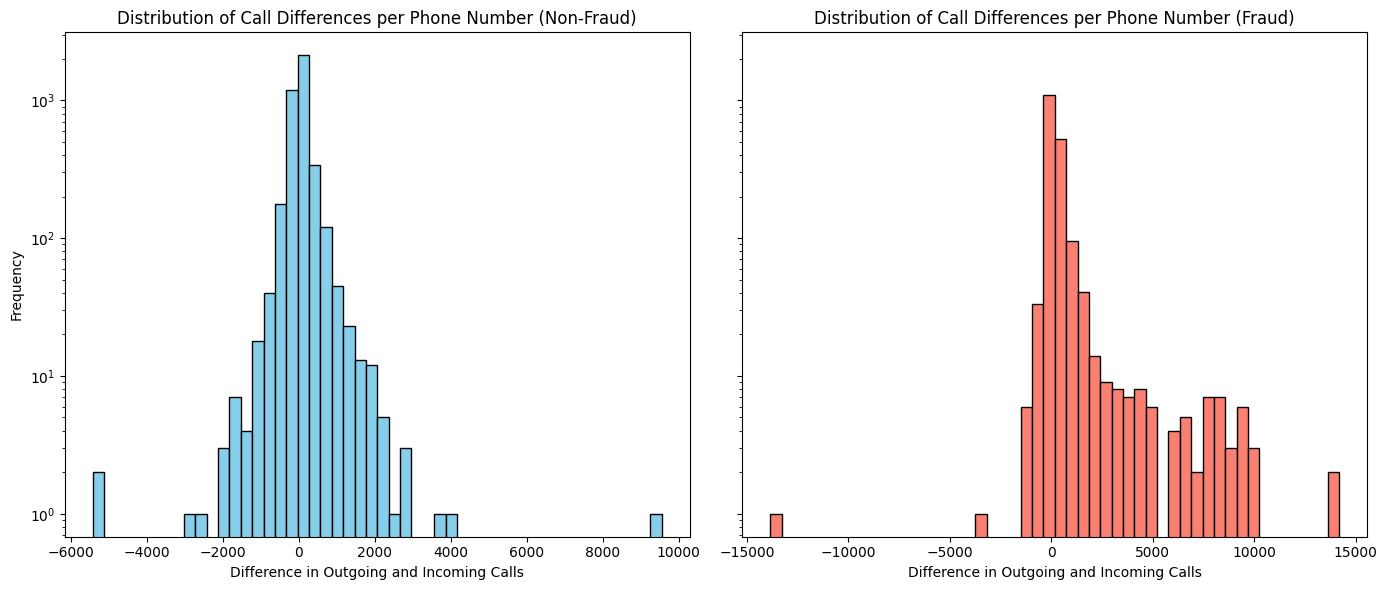

In [21]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# For non-fraud phone numbers
non_fraud_call_type_diff_counts = non_fraud_data_voc.groupby('phone_no_m')['calltype_id'].apply(lambda x: (x == 1).sum() - (x == 2).sum())
axes[0].hist(non_fraud_call_type_diff_counts, bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Call Differences per Phone Number (Non-Fraud)')
axes[0].set_xlabel('Difference in Outgoing and Incoming Calls')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# For fraud phone numbers
fraud_call_type_diff_counts = fraud_data_voc.groupby('phone_no_m')['calltype_id'].apply(lambda x: (x == 1).sum() - (x == 2).sum())
axes[1].hist(fraud_call_type_diff_counts, bins=50, edgecolor='black', color='salmon')
axes[1].set_title('Distribution of Call Differences per Phone Number (Fraud)')
axes[1].set_xlabel('Difference in Outgoing and Incoming Calls')
axes[1].set_yscale('log')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()

In [22]:
print(data_og_voc['call_dur'].describe())

count    5.015430e+06
mean     8.106088e+01
std      1.893270e+02
min      0.000000e+00
25%      1.700000e+01
50%      3.400000e+01
75%      7.300000e+01
max      2.159800e+04
Name: call_dur, dtype: float64


In [23]:
print(non_fraud_data_voc['call_dur'].describe())

count    3.534736e+06
mean     8.545717e+01
std      1.930493e+02
min      1.000000e+00
25%      1.900000e+01
50%      3.700000e+01
75%      7.700000e+01
max      2.159400e+04
Name: call_dur, dtype: float64


In [24]:
print(fraud_data_voc['call_dur'].describe())

count    1.480694e+06
mean     7.056599e+01
std      1.796962e+02
min      0.000000e+00
25%      1.400000e+01
50%      2.800000e+01
75%      6.200000e+01
max      2.159800e+04
Name: call_dur, dtype: float64


#### Call Duration Statistics

- **Count**: 5,015,430 → Approximately 5 million call records.
- **Mean**: 81.06 seconds → The average call duration is 81 seconds.
- **Standard Deviation (std)**: 189.33 seconds → Call durations vary widely, with many calls being much shorter or longer than the mean.
- **Minimum (min)**: 0 seconds → Some calls had a duration of 0 seconds, likely indicating unanswered or immediately dropped calls.
- **25th Percentile (Q1)**: 17 seconds → 25% of calls lasted 17 seconds or less.
- **Median (Q2)**: 34 seconds → Half of the calls lasted 34 seconds or less.
- **75th Percentile (Q3)**: 73 seconds → 75% of calls lasted 73 seconds or less.
- **Maximum (max)**: 21,598 seconds (~6 hours) → Some calls lasted exceptionally long, likely representing outliers.

#### Observations
- The mean is significantly higher than the median, indicating the presence of extreme outliers with very long durations.

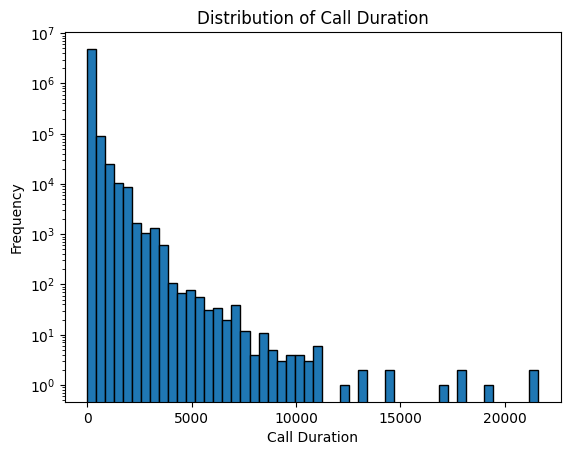

In [25]:
plt.hist(data_og_voc['call_dur'], bins=50, edgecolor='black', log=True)  # Adjust bins as needed
plt.xlabel("Call Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Call Duration")
plt.show()
# a lot of calls are very short, so probs ppl call wrong/spam call

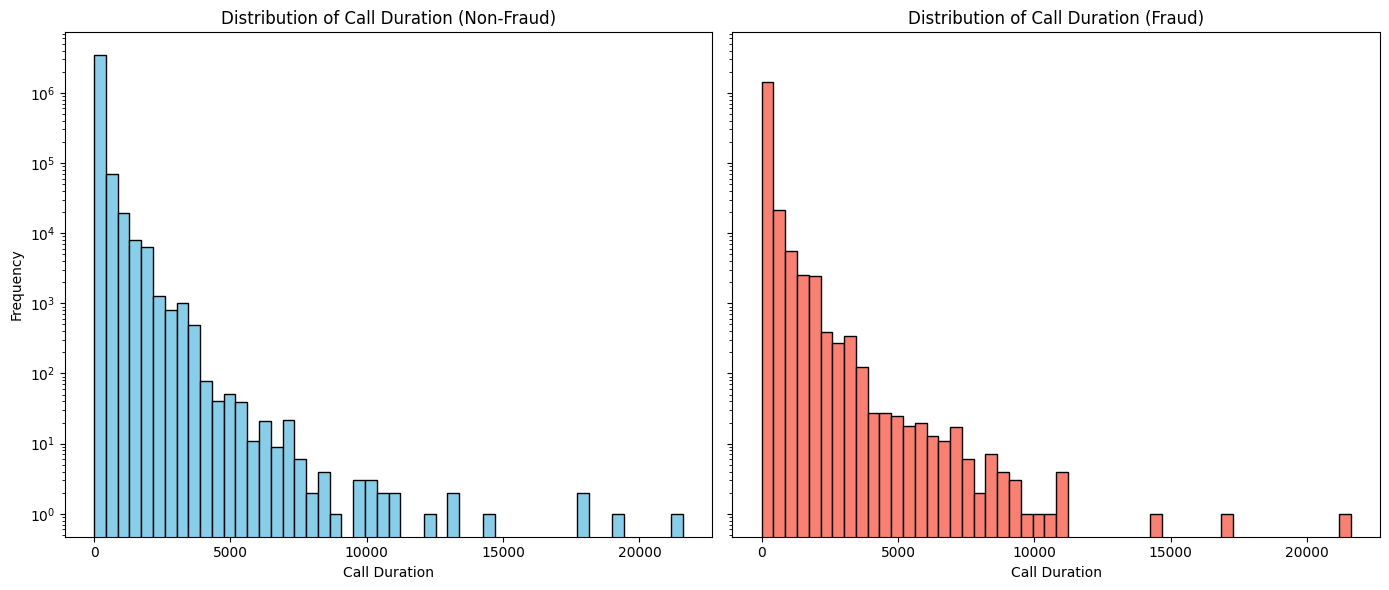

In [26]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_data_voc['call_dur'], bins=50, edgecolor='black', color='skyblue', log=True)
axes[0].set_title("Distribution of Call Duration (Non-Fraud)")
axes[0].set_xlabel("Call Duration")
axes[0].set_ylabel("Frequency")

# Plot histogram for fraud data
axes[1].hist(fraud_data_voc['call_dur'], bins=50, edgecolor='black', color='salmon', log=True)
axes[1].set_title("Distribution of Call Duration (Fraud)")
axes[1].set_xlabel("Call Duration")

# Adjust layout for better visibility
plt.tight_layout()
plt.show()

Call Durations have quite similar distributions

In [27]:
# Get histogram counts and bin edges
counts, bin_edges = np.histogram(data_og_voc['call_dur'], bins=100)

# Create a DataFrame to display bin edges and counts
hist_df = pd.DataFrame({
    'bin_start': bin_edges[:-1],
    'bin_end': bin_edges[1:],
    'count': counts
})

print(hist_df[hist_df['count'] != 0])

    bin_start   bin_end    count
0        0.00    215.98  4662133
1      215.98    431.96   212732
2      431.96    647.94    62917
3      647.94    863.92    28151
4      863.92   1079.90    15402
5     1079.90   1295.88     9452
6     1295.88   1511.86     6265
7     1511.86   1727.84     4339
8     1727.84   1943.82     6986
9     1943.82   2159.80     1859
10    2159.80   2375.78      942
11    2375.78   2591.76      722
12    2591.76   2807.74      601
13    2807.74   3023.72      472
14    3023.72   3239.70      366
15    3239.70   3455.68      975
16    3455.68   3671.66      428
17    3671.66   3887.64      194
18    3887.64   4103.62       64
19    4103.62   4319.60       42
20    4319.60   4535.58       39
21    4535.58   4751.56       29
22    4751.56   4967.54       42
23    4967.54   5183.52       34
24    5183.52   5399.50       33
25    5399.50   5615.48       24
26    5615.48   5831.46       14
27    5831.46   6047.44       17
28    6047.44   6263.42       21
29    6263

#### This section analyzes the relationships between phone numbers, such as identifying recurring interactions or mutual connections. This helps uncover patterns, like frequent calls between specific numbers, which may indicate a closer relationship or unusual behavior.

In [28]:
# Group by 'opposite_no_m' and get the phone_no_m values in each group
grouped = data_og_voc.groupby('opposite_no_m')['phone_no_m'].apply(list)

# Filter groups where there is more than 1 phone_no_m (cos most opposite phone nos only call once)
filtered_groups = grouped[grouped.apply(len) > 1]

In [29]:
# Count unique phone_no_m in each list
unique_counts = filtered_groups.apply(lambda x: len(set(x)))
print(unique_counts.value_counts())

# most opposite phone numbers only recieve/call one other person (more than once, cos we filtered out for those that only called once)
# but one opposite phone number called/recieved phone numbers from 2136 people (most extreme)

phone_no_m
1       289474
2        28953
3         4134
4         1860
5         1038
6          548
7          385
8          266
9          135
10          73
11          42
12          34
14          26
15          22
13          19
16          18
17          17
19          17
21          15
18          14
20          12
23          10
36          10
25           8
27           8
26           8
29           8
40           8
31           7
22           6
35           5
24           5
28           5
39           5
44           4
69           4
52           4
43           4
50           4
38           4
66           3
51           3
37           3
48           3
53           3
125          2
82           2
76           2
57           2
49           2
42           2
46           2
30           2
95           2
67           2
32           2
58           2
33           2
131          2
47           2
93           1
64           1
68           1
184          1
99           1
63           1

In [30]:
# Find the 'opposite_no_m' where the unique count is the maximum
max_opposite_no_m = unique_counts.idxmax()

# Get the value (number of unique phone_no_m) for the max 'opposite_no_m'
max_unique_count = unique_counts[max_opposite_no_m]

print(f"The 'opposite_no_m' with the maximum number of unique 'phone_no_m' is: {max_opposite_no_m}")
print(f"It has {max_unique_count} unique 'phone_no_m'.")

The 'opposite_no_m' with the maximum number of unique 'phone_no_m' is: df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f06ee093a91c4a41385d46579107a443eee3ec0ce2339bcea4152a996ca8cf0b2cc846eb2acc9cc241b
It has 2136 unique 'phone_no_m'.


In [31]:
# want to find out how many of the calls made by/to this opposite number are incoming and outgoing (kinda switched everything around)
filtered_data = data_og_voc[data_og_voc['calltype_id'] == 1]

# Group by 'opposite_no_m' and count the occurrences
grouped_counts = filtered_data.groupby('opposite_no_m').count()

# Print the count for the specific 'opposite_no_m'
print(grouped_counts.loc['df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f06ee093a91c4a41385d46579107a443eee3ec0ce2339bcea4152a996ca8cf0b2cc846eb2acc9cc241b'])

# most of the calls are outgoing to this number (7516), only 335 are incoming (so this number is the one that called)
# kinda expected this opposite number to be the one making most of the calls...

phone_no_m        7516
calltype_id       7516
start_datetime    7516
call_dur          7516
city_name         5331
county_name       5331
imei_m            7516
Name: df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f06ee093a91c4a41385d46579107a443eee3ec0ce2339bcea4152a996ca8cf0b2cc846eb2acc9cc241b, dtype: int64


Observe how many calls happen per day, check if constant over time

In [32]:
# Convert 'start_datetime' to datetime if it's not already
data_og_voc['start_datetime'] = pd.to_datetime(data_og_voc['start_datetime'])

# Extract date part from 'start_datetime'
data_og_voc['date'] = data_og_voc['start_datetime'].dt.date

# Group by 'date' and count the number of calls made for each date
phone_counts_per_date = data_og_voc.groupby('date')['phone_no_m'].count()

# Print the counts per date
print(phone_counts_per_date.describe())

count      244.000000
mean     20555.040984
std       4217.942895
min      11515.000000
25%      17819.750000
50%      19737.000000
75%      23471.250000
max      30663.000000
Name: phone_no_m, dtype: float64


/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3942279751.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_data_voc['start_datetime'] = pd.to_datetime(fraud_data_voc['start_datetime'])
/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3942279751.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_fraud_data_voc['start_datetime'] = pd.to_datetime(non_fraud_data_voc['start_datetime'])
/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3942279751.py:6

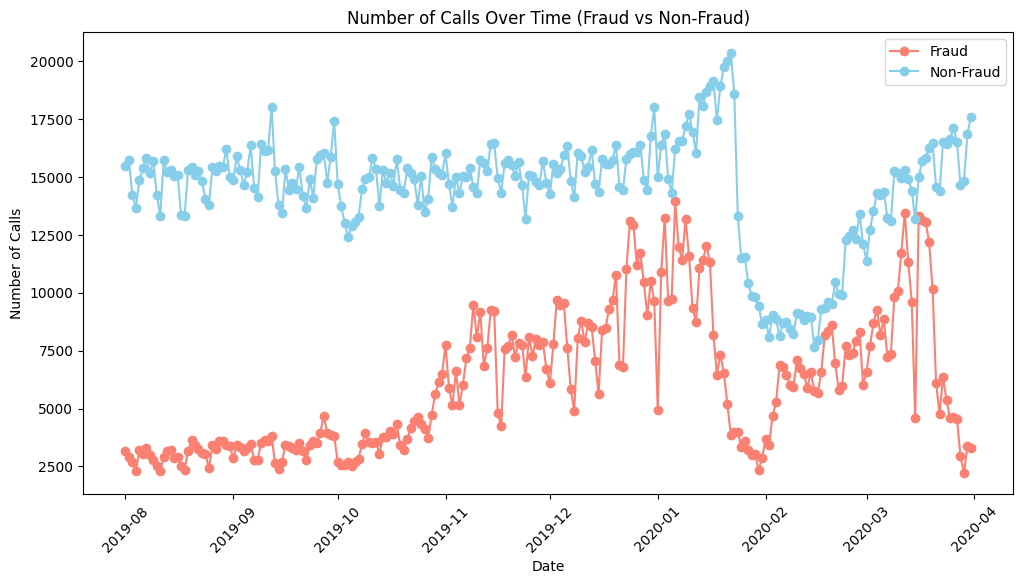

In [30]:
# Convert 'start_datetime' to datetime for both fraud and non-fraud data if not already
fraud_data_voc['start_datetime'] = pd.to_datetime(fraud_data_voc['start_datetime'])
non_fraud_data_voc['start_datetime'] = pd.to_datetime(non_fraud_data_voc['start_datetime'])

# Extract the date part from 'start_datetime' for both datasets
fraud_data_voc['date'] = fraud_data_voc['start_datetime'].dt.date
non_fraud_data_voc['date'] = non_fraud_data_voc['start_datetime'].dt.date

# Group by 'date' and count the number of calls made for each date
fraud_counts_per_date = fraud_data_voc.groupby('date')['phone_no_m'].count()
non_fraud_counts_per_date = non_fraud_data_voc.groupby('date')['phone_no_m'].count()

# Plot the number of calls over time for both fraud and non-fraud data
plt.figure(figsize=(12, 6))

# Plot for fraud data
plt.plot(fraud_counts_per_date, marker='o', linestyle='-', color='salmon', label='Fraud')

# Plot for non-fraud data
plt.plot(non_fraud_counts_per_date, marker='o', linestyle='-', color='skyblue', label='Non-Fraud')

# Add labels, title, and legend
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.title("Number of Calls Over Time (Fraud vs Non-Fraud)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()

# Show the plot
plt.show()

Non-fraud calls remain relatively constant over time, with a noticeable dip during the Chinese New Year holiday, possibly due to reduced activity. The subsequent spike might indicate efforts to catch up on work. fraud calls, on the other hand, exhibit a cyclic trend. 

(January 24 to January 30 marks the Spring Festival holiday, extended to February 2 due to COVID-19 containment measures.)

#### User Dataset

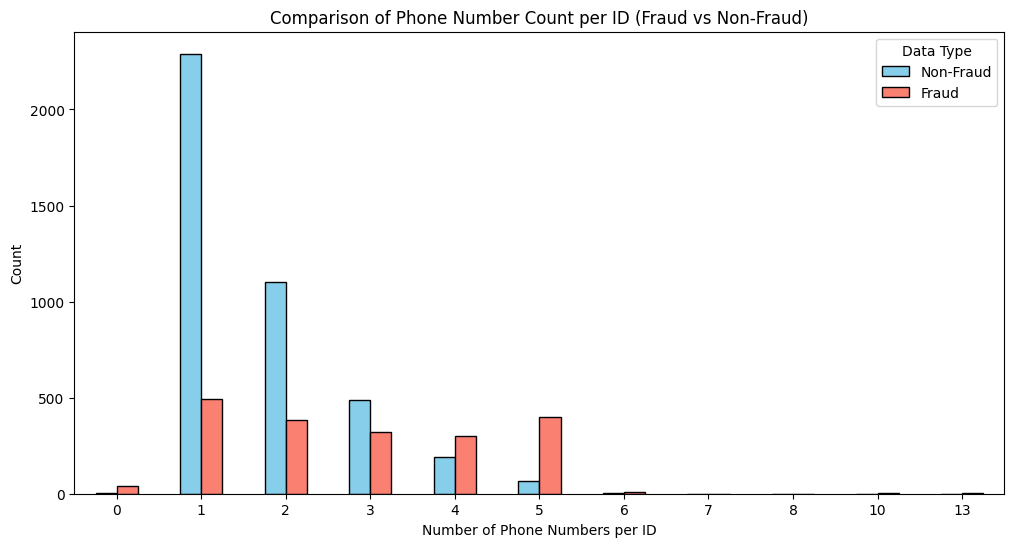

In [34]:
# Count phone numbers per ID for non-fraud and fraud data
non_fraud_id_counts = non_fraud_data_user['idcard_cnt'].value_counts()
fraud_id_counts = fraud_data_user['idcard_cnt'].value_counts()

# Combine the counts into a single DataFrame for comparison
comparison_df = pd.DataFrame({
    'Non-Fraud': non_fraud_id_counts,
    'Fraud': fraud_id_counts
}).fillna(0)  # Fill NaN values with 0

# Plot the comparison
comparison_df.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'], edgecolor='black')
plt.title("Comparison of Phone Number Count per ID (Fraud vs Non-Fraud)")
plt.xlabel("Number of Phone Numbers per ID")
plt.ylabel("Count")
plt.xticks(rotation=360)
plt.legend(title="Data Type")
plt.show()


In [5]:
# Only consider numeric columns
numeric_cols = data_og_user.select_dtypes(include='number').columns

# Check if any value in those columns is negative
rows_with_negative = data_og_user[(data_og_user[numeric_cols] < 0).any(axis=1)]

# check rows where arpu is negative
print(len(rows_with_negative))
print(rows_with_negative)

7
                                             phone_no_m city_name county_name  idcard_cnt  arpu_201908  arpu_201909  arpu_201910  arpu_201911  arpu_201912  arpu_202001  arpu_202002  arpu_202003  label
339   c5502a6d3e4cabaf8c0e298c4aac693b6e80835d50d4e4...        自贡       荣县分公司           4          NaN          NaN          NaN          NaN       -12.17        37.60        38.45        44.20      0
506   a2136d40469824765dae4eea6bd7d572c1c5f78c7bdbb8...        德阳       什邡分公司           1          NaN          NaN          NaN          NaN       -54.74        11.66         9.00         9.00      0
518   f759d185723a1e33020aba047b14f4c6232254221a95cc...        德阳       中江分公司           3          NaN          NaN          NaN          NaN          NaN          NaN          NaN        -4.36      0
3159  cf8ba8314c903c9ea6eeb08f4db8349c20bc8329d74a96...        自贡       贡井分公司           2          NaN          NaN          NaN          NaN       -47.27        25.53        15.84        14.13 

/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3585201475.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '426.40000000000003' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  count_data.loc[0] = count_data.loc[0] * 0.8  # Scale down by 80%


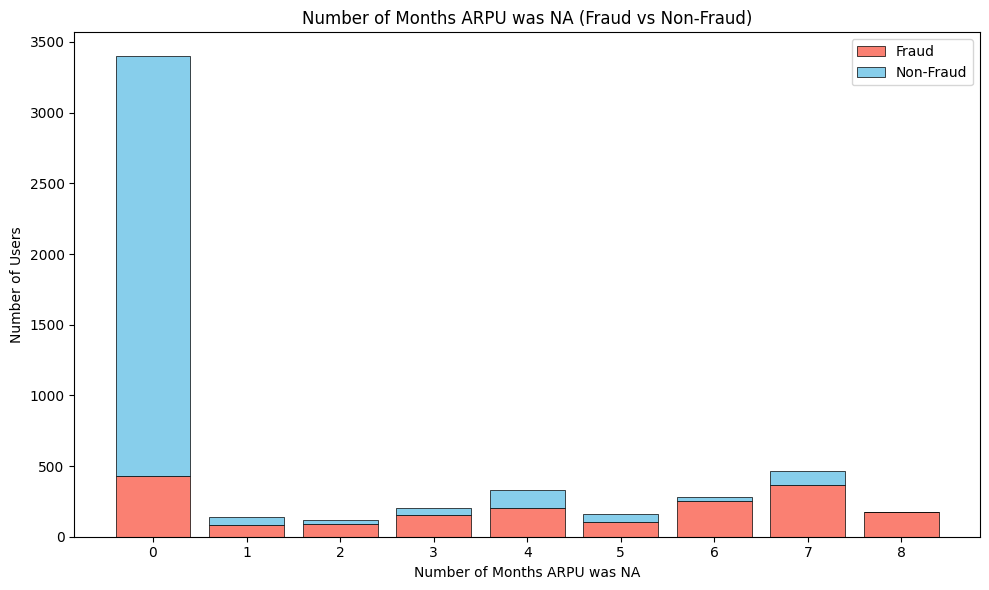

In [15]:
# Define ARPU columns
arpu_cols = [col for col in data_og_user.columns if col.startswith("arpu_")]

# Count number of NA ARPU columns per row
data_og_user["arpu_na_count"] = data_og_user[arpu_cols].isnull().sum(axis=1)

# Get count of users per (arpu_na_count, label) combo
count_data = data_og_user.groupby(["arpu_na_count", "label"]).size().unstack(fill_value=0)

# Reduce height of first column (x = 0)
if 0 in count_data.index:
    count_data.loc[0] = count_data.loc[0] * 0.8  # Scale down by 80%

# Set up bar positions and width
x_vals = count_data.index
bar_width = 0.8

plt.figure(figsize=(10, 6))
bottoms = [0] * len(x_vals)

# Plot bars with borders and counts
for label_val, color in zip([1, 0], ["salmon", "skyblue"]):
    heights = count_data[label_val].values
    plt.bar(
        x_vals,
        heights,
        bottom=bottoms,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        label="Fraud" if label_val == 1 else "Non-Fraud"
    )
    bottoms = [b + h for b, h in zip(bottoms, heights)]

# Customize
plt.title("Number of Months ARPU was NA (Fraud vs Non-Fraud)")
plt.xlabel("Number of Months ARPU was NA")
plt.ylabel("Number of Users")
plt.xticks(x_vals)
plt.legend()
plt.tight_layout()
plt.show()

In [139]:
counts_by_label = data_og_user.groupby("label")["arpu_na_count"].value_counts().sort_index()

# Print result in a readable format
print(counts_by_label)

label  arpu_na_count
0      0                3715
       1                  54
       2                  24
       3                  46
       4                 129
       5                  54
       6                  25
       7                  97
1      0                 533
       1                  82
       2                  92
       3                 156
       4                 202
       5                 105
       6                 253
       7                 365
       8                 174
Name: count, dtype: int64


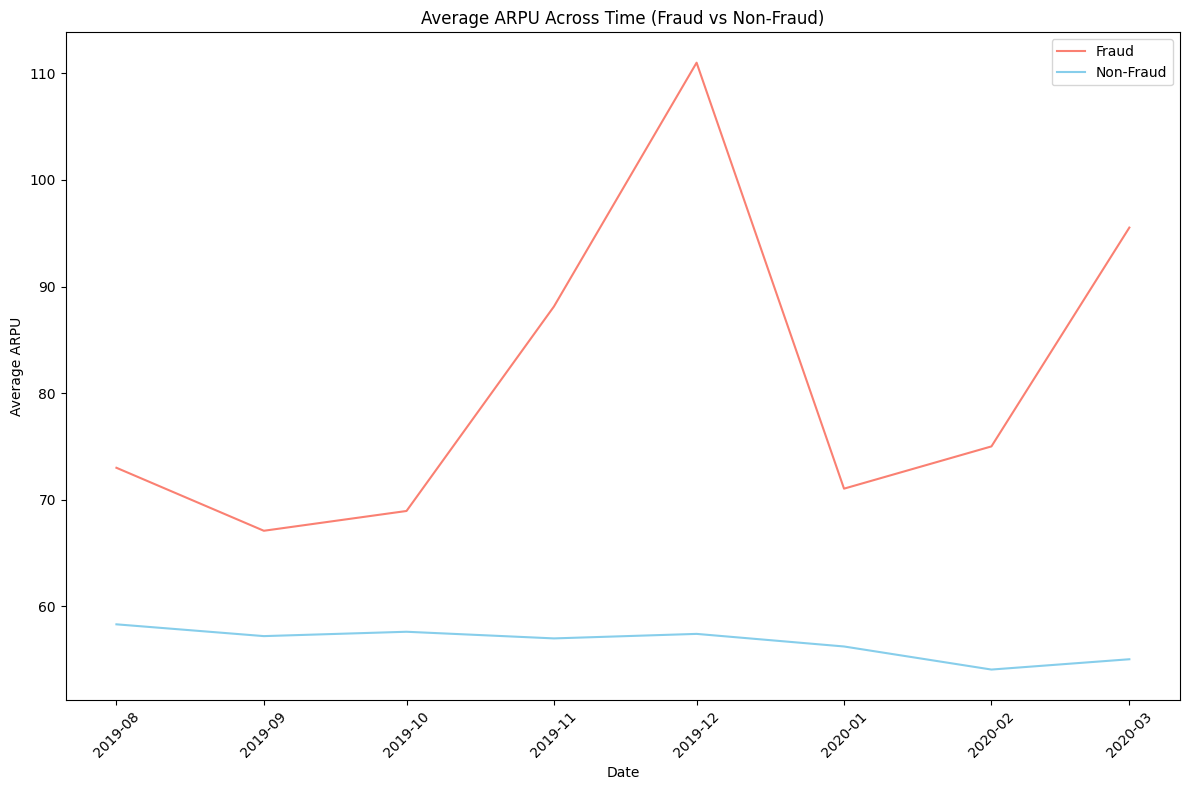

In [35]:
# Extract the 'arpu' columns
arpu_columns = [
    'arpu_201908', 'arpu_201909', 'arpu_201910', 'arpu_201911', 'arpu_201912',
    'arpu_202001', 'arpu_202002', 'arpu_202003'
]

# Reshape the fraud data: Convert the wide format into long format
df_long_fraud = fraud_data_user.melt(id_vars=['phone_no_m'], value_vars=arpu_columns,
                                   var_name='month', value_name='arpu')
df_long_fraud['month'] = pd.to_datetime(df_long_fraud['month'], format='arpu_%Y%m')
monthly_avg_arpu_fraud = df_long_fraud.groupby('month')['arpu'].mean()

# Reshape the non-fraud data: Convert the wide format into long format
df_long_non_fraud = non_fraud_data_user.melt(id_vars=['phone_no_m'], value_vars=arpu_columns,
                                           var_name='month', value_name='arpu')
df_long_non_fraud['month'] = pd.to_datetime(df_long_non_fraud['month'], format='arpu_%Y%m')
monthly_avg_arpu_non_fraud = df_long_non_fraud.groupby('month')['arpu'].mean()

# Plot the average ARPU across time for both fraud and non-fraud data
plt.figure(figsize=(12, 8))
plt.plot(monthly_avg_arpu_fraud.index, monthly_avg_arpu_fraud.values, label='Fraud', color='salmon')
plt.plot(monthly_avg_arpu_non_fraud.index, monthly_avg_arpu_non_fraud.values, label='Non-Fraud', color='skyblue')

# Title and labels
plt.title('Average ARPU Across Time (Fraud vs Non-Fraud)')
plt.xlabel('Date')
plt.ylabel('Average ARPU')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Apply tight layout for better spacing
plt.tight_layout()

plt.show()


#### SMS Related

/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3253641368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_fraud_data_sms['request_datetime'] = pd.to_datetime(non_fraud_data_sms['request_datetime'])
/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3253641368.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_data_sms['request_datetime'] = pd.to_datetime(fraud_data_sms['request_datetime'])
/var/folders/yb/lf5c23g50c77xppz7lz86zn80000gn/T/ipykernel_66331/3253641

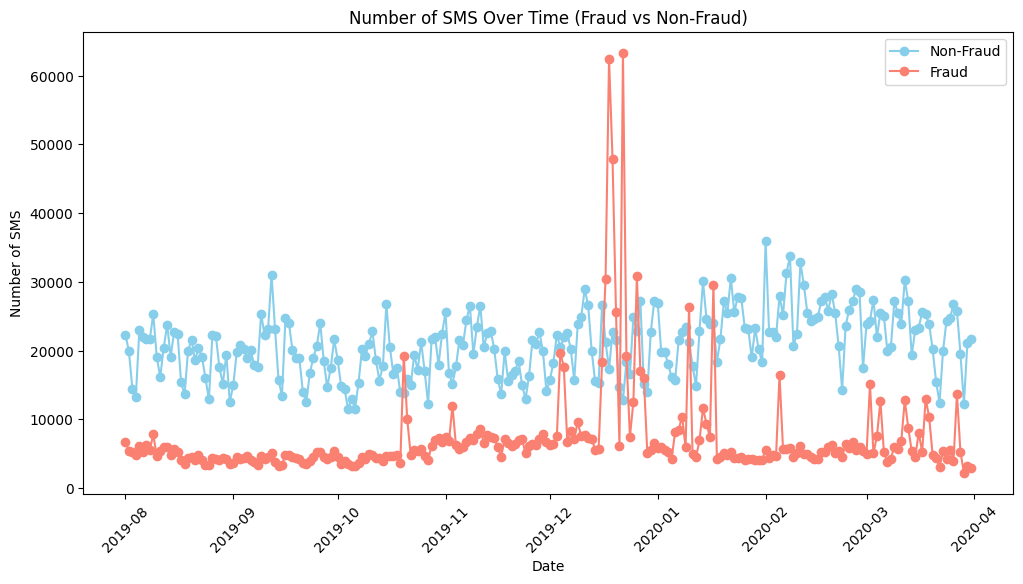

In [67]:
# Convert 'request_datetime' to datetime if it's not already
non_fraud_data_sms['request_datetime'] = pd.to_datetime(non_fraud_data_sms['request_datetime'])
fraud_data_sms['request_datetime'] = pd.to_datetime(fraud_data_sms['request_datetime'])

# Extract date part from 'request_datetime'
non_fraud_data_sms['date'] = non_fraud_data_sms['request_datetime'].dt.date
fraud_data_sms['date'] = fraud_data_sms['request_datetime'].dt.date

# Group by 'date' and count the number of SMS for each date
non_fraud_sms_counts_per_date = non_fraud_data_sms.groupby('date')['phone_no_m'].count()
fraud_sms_counts_per_date = fraud_data_sms.groupby('date')['phone_no_m'].count()

# Plot both fraud and non-fraud SMS counts over time
plt.figure(figsize=(12, 6))
plt.plot(non_fraud_sms_counts_per_date, marker='o', linestyle='-', color='skyblue', label='Non-Fraud')
plt.plot(fraud_sms_counts_per_date, marker='o', linestyle='-', color='salmon', label='Fraud')

# Add labels, title, and legend
plt.xlabel("Date")
plt.ylabel("Number of SMS")
plt.title("Number of SMS Over Time (Fraud vs Non-Fraud)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()

# Show the plot
plt.show()


#### App Related

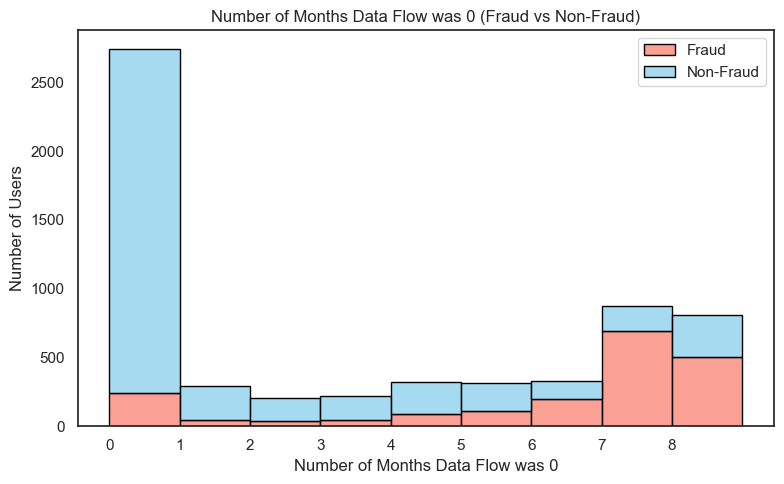

In [135]:
# Drop rows where month_id is NaN (the flow is 0 when month_id is NA) - some rows will have 0 flow but non-zero month_id (these just never use these apps)
flow_data_valid = data_og_app.dropna(subset=["month_id"])

# Group by phone_no_m and month_id, then sum flow
monthly_flow = flow_data_valid.groupby(["phone_no_m", "month_id"])["flow"].sum().reset_index()

# Rename for clarity (optional)
monthly_flow.rename(columns={"flow": "monthly_flow"}, inplace=True)


monthly_flow_wide = monthly_flow.pivot_table(
    index="phone_no_m",
    columns="month_id",
    values="monthly_flow",
).reset_index()


monthly_flow_wide["label"] = 0

# Set label to 1 where phone_no_m is in fraud_numbers
monthly_flow_wide.loc[monthly_flow_wide["phone_no_m"].isin(fraud_numbers), "label"] = 1

monthly_flow_wide["empty_months"] = monthly_flow_wide.drop(columns=["phone_no_m", "label"]).isna().sum(axis=1)


# Filter rows with missing month_id
missing_month = data_og_app[data_og_app["month_id"].isna()]

# Group by phone_no_m and sum the flow for rows with missing month_id
missing_month_grouped = missing_month.groupby("phone_no_m")["flow"].sum().reset_index()

# Add a new column "empty_months" with value 8 for missing month rows
missing_month_grouped["empty_months"] = 8

# Add label for fraud (assuming missing data means label 0 by default)
missing_month_grouped["label"] = 0
missing_month_grouped.loc[missing_month_grouped["phone_no_m"].isin(fraud_numbers), "label"] = 1

# Now, combine the monthly_flow_wide data with the missing_month_grouped data
# For users with non-missing months
monthly_flow_wide["empty_months"] = monthly_flow_wide.drop(columns=["phone_no_m", "label"]).isna().sum(axis=1)

# Concatenate the two dataframes
combined_data = pd.concat([monthly_flow_wide[['phone_no_m', 'label', 'empty_months']], missing_month_grouped[['phone_no_m', 'label', 'empty_months']]])


# Plot
plt.figure(figsize=(8, 5))
sns.histplot(
    data=combined_data,
    x="empty_months",
    hue="label",
    multiple="stack",
    palette={0: "skyblue", 1: "salmon"},
    bins=range(0, combined_data["empty_months"].max() + 2),
    hue_order=[0, 1],  # Ensure that the legend order is correct (Non-Fraud first, then Fraud)
    edgecolor='black'
)

# Set the labels and title
plt.xlabel("Number of Months Data Flow was 0")
plt.ylabel("Number of Users")
plt.title("Number of Months Data Flow was 0 (Fraud vs Non-Fraud)")
plt.xticks(range(0, combined_data["empty_months"].max() + 1))

# Set the legend labels
plt.legend(labels=["Fraud", "Non-Fraud"])

# Tight layout
plt.tight_layout()
plt.show()

In [89]:
# Filter rows where month_id is NaN
na_month_rows = data_og_app[data_og_app["month_id"].isna()]

# Count duplicate phone numbers
duplicate_phones = na_month_rows["phone_no_m"].duplicated(keep=False)
num_duplicates = duplicate_phones.sum()

print("Number of duplicate phone numbers (with at least one duplicate):", num_duplicates)

Number of duplicate phone numbers (with at least one duplicate): 0


In [90]:
# Find duplicated phone numbers
duplicates = combined_data[combined_data["phone_no_m"].duplicated(keep=False)]

# Print number of duplicate rows
print("Number of duplicated phone_no_m entries:", duplicates.shape[0])

# Optionally, see which phone numbers are duplicated
duplicated_phones = combined_data["phone_no_m"].value_counts()
duplicated_phones = duplicated_phones[duplicated_phones > 1]
print("Duplicated phone numbers:\n", duplicated_phones)

Number of duplicated phone_no_m entries: 0
Duplicated phone numbers:
 Series([], Name: count, dtype: int64)


### More In-Depth Data Exploration

#### Distribution Patterns between Fraud and Non-fraud on Specific Features

##### Histogram

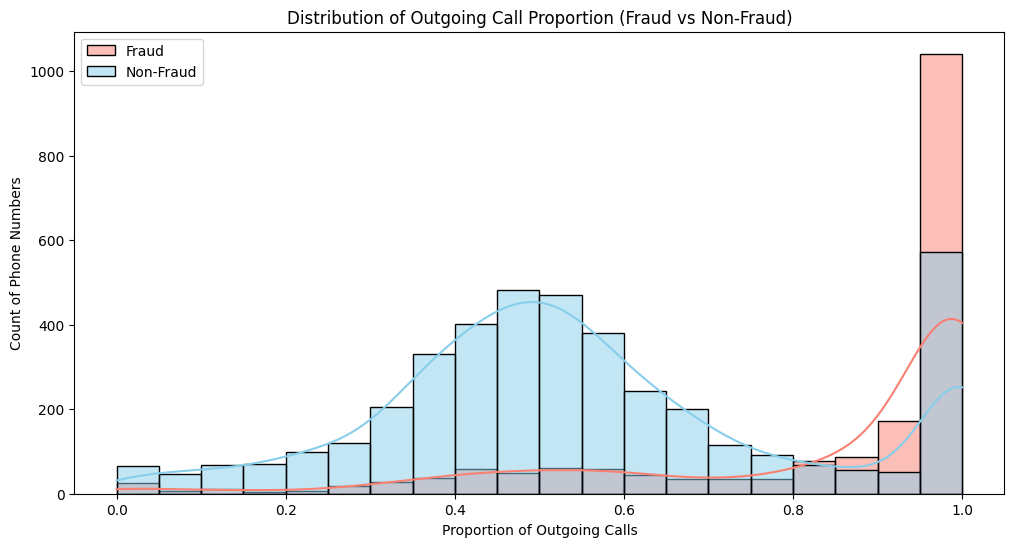

In [37]:
# For label 1 and 0 , plot the distribution of 'voc_calltype1_proportion' in 0.05 bins
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 1]['voc_calltype1_proportion'], bins=np.arange(0, 1.05, 0.05), color='salmon', label='Fraud', kde=True)
sns.histplot(df[df['label'] == 0]['voc_calltype1_proportion'], bins=np.arange(0, 1.05, 0.05), color='skyblue', label='Non-Fraud', kde=True)
plt.title('Distribution of Outgoing Call Proportion (Fraud vs Non-Fraud)')
plt.xlabel("Proportion of Outgoing Calls")
plt.ylabel("Count of Phone Numbers")
plt.legend()
plt.show()


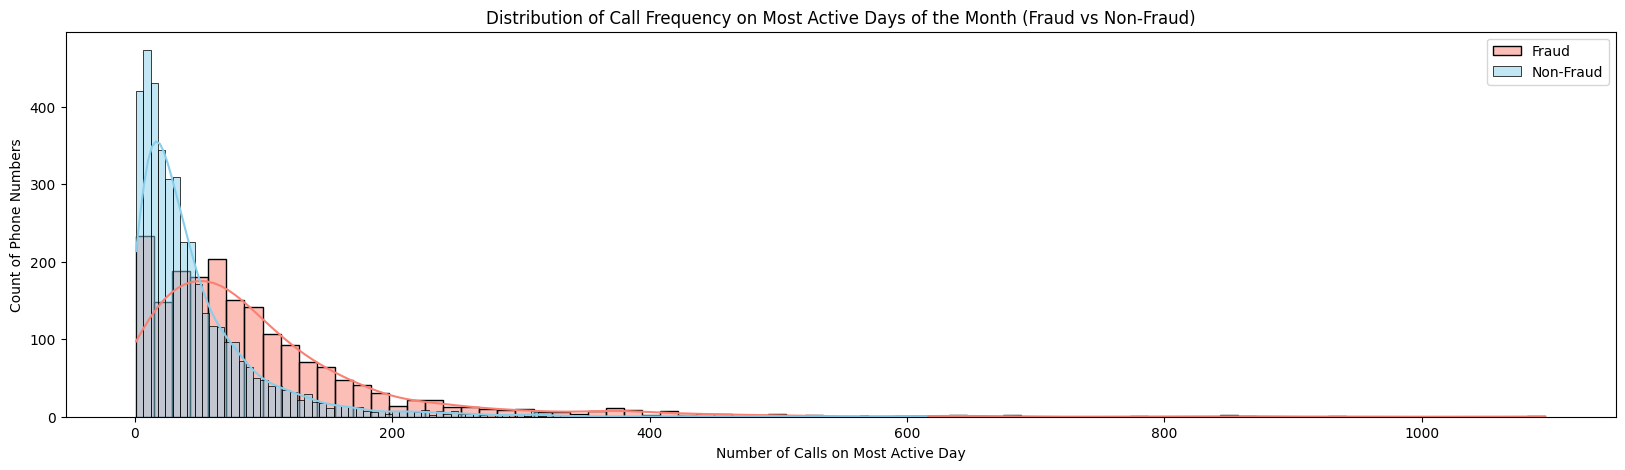

In [38]:
# For label 1 and 0 , plot the distribution of VOC Day Mode Count 
plt.figure(figsize=(20,5)) 
sns.histplot(df[df['label']==1]['voc_day_mode_count'], color='salmon', label='Fraud', kde=True)
sns.histplot(df[df['label']==0]['voc_day_mode_count'], color='skyblue', label='Non-Fraud', kde=True)
plt.legend()
plt.xlabel("Number of Calls on Most Active Day")
plt.ylabel("Count of Phone Numbers")
plt.title("Distribution of Call Frequency on Most Active Days of the Month (Fraud vs Non-Fraud)")
plt.show()

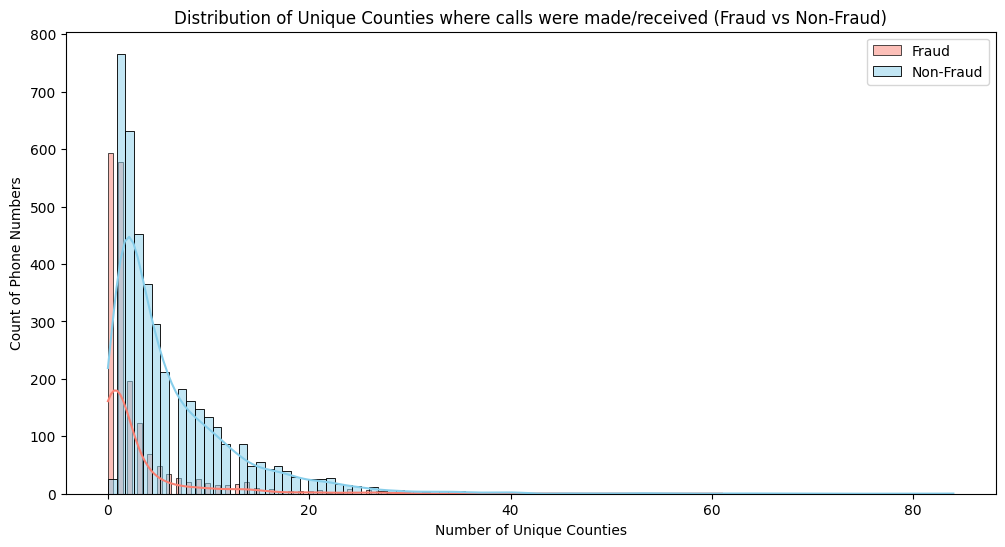

In [39]:
# For label 1 and 0 , plot the distribution of 'call_county_unique' 
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 1]['call_county_unique'], color='salmon', label='Fraud', kde=True)
sns.histplot(df[df['label'] == 0]['call_county_unique'], color='skyblue', label='Non-Fraud', kde=True)
plt.title('Distribution of Unique Counties where calls were made/received (Fraud vs Non-Fraud)')
plt.xlabel("Number of Unique Counties")
plt.ylabel("Count of Phone Numbers")
plt.legend()
plt.show()



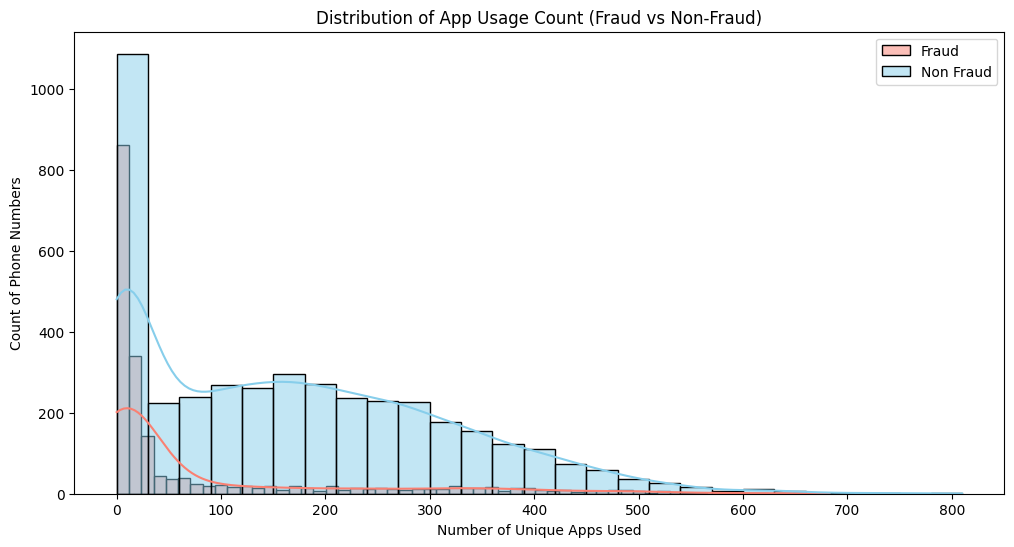

In [40]:
# For label 1 and 0 , plot the distribution of 'app_usage_count' 
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 1]['app_usage_count'], color='salmon', label='Fraud', kde=True)
sns.histplot(df[df['label'] == 0]['app_usage_count'], color='skyblue', label='Non Fraud', kde=True)
plt.title('Distribution of App Usage Count (Fraud vs Non-Fraud)')
plt.xlabel("Number of Unique Apps Used")
plt.ylabel("Count of Phone Numbers")
plt.legend()
plt.show()

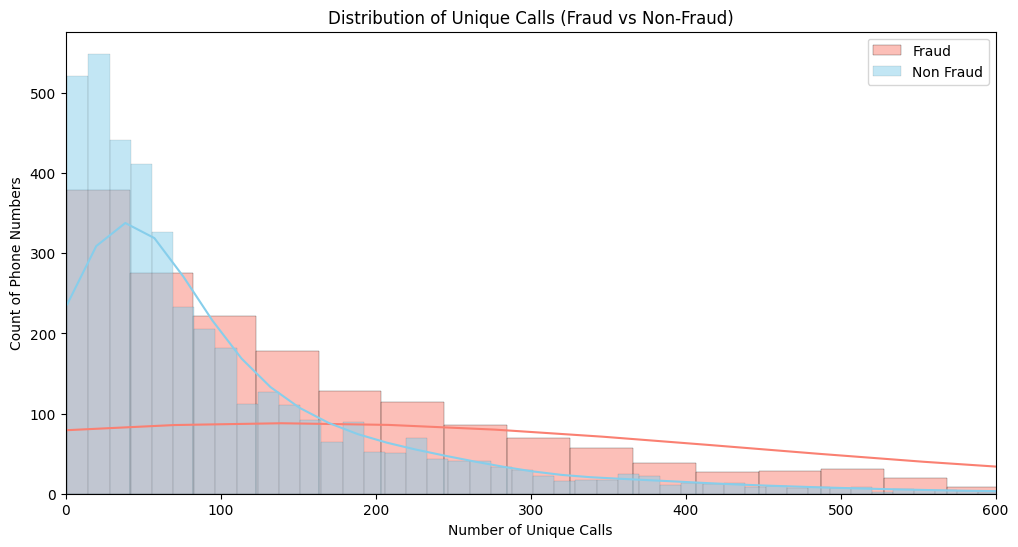

In [41]:
# For label 1 and 0 , plot the distribution of 'call_unique' 
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 1]['call_unique'], color='salmon', label='Fraud', kde=True)
sns.histplot(df[df['label'] == 0]['call_unique'], color='skyblue', label='Non Fraud', kde=True)
plt.title('Distribution of Unique Calls (Fraud vs Non-Fraud)')
plt.xlabel("Number of Unique Calls")
plt.ylabel("Count of Phone Numbers")
plt.legend()
plt.xlim(0, 600)
plt.show()

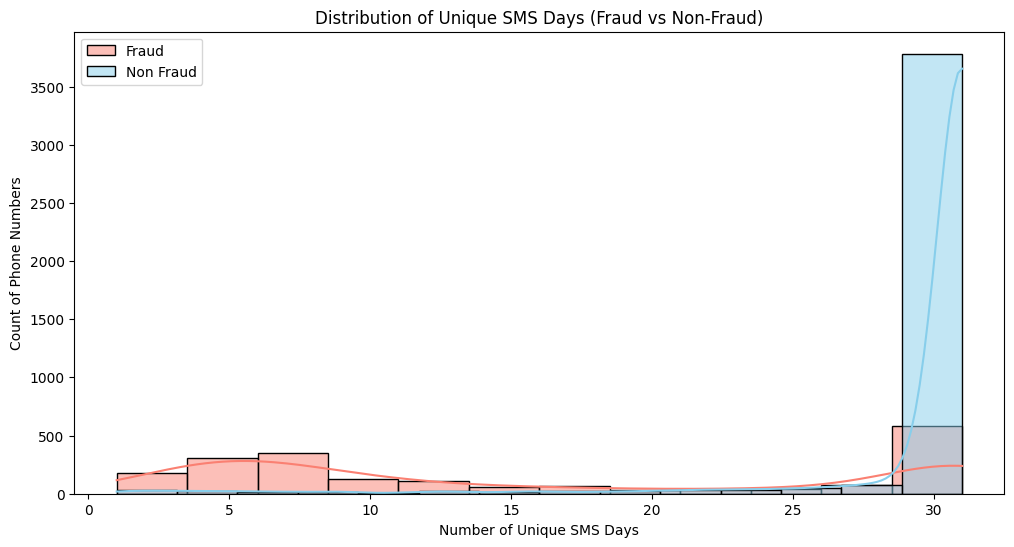

In [42]:
# For label 1 and 0 , plot the distribution of 'sms_day_nunique'
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 1]['sms_day_nunique'], color='salmon', label='Fraud', kde=True)
sns.histplot(df[df['label'] == 0]['sms_day_nunique'], color='skyblue', label='Non Fraud', kde=True)
plt.title('Distribution of Unique SMS Days (Fraud vs Non-Fraud)')
plt.xlabel("Number of Unique SMS Days")
plt.ylabel("Count of Phone Numbers")
plt.legend()
plt.show() 

In [43]:
fraud_data = df[df['label'] == 1]
non_fraud_data = df[df['label'] == 0]

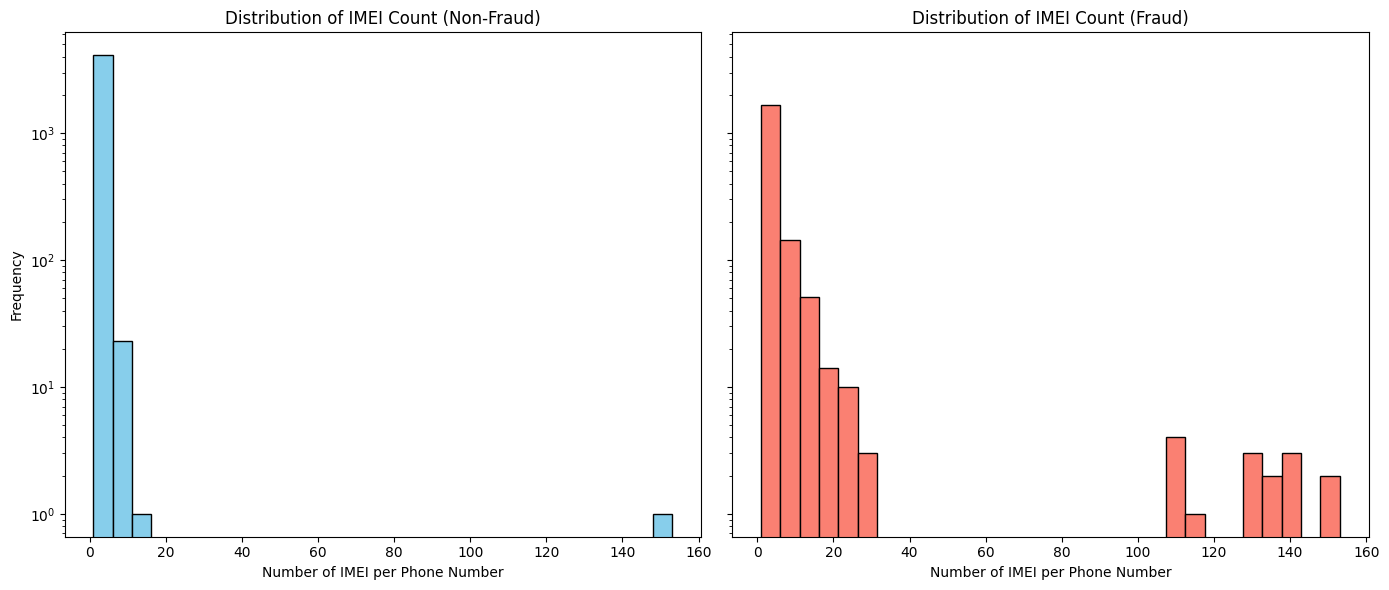

In [44]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_data['imei_count'], bins=30, edgecolor='black', log=True, color='skyblue')
axes[0].set_title('Distribution of IMEI Count (Non-Fraud)')
axes[0].set_xlabel('Number of IMEI per Phone Number')
axes[0].set_ylabel('Frequency')

# Plot histogram for fraud data
axes[1].hist(fraud_data['imei_count'], bins=30, edgecolor='black', log=True, color='salmon')
axes[1].set_title('Distribution of IMEI Count (Fraud)')
axes[1].set_xlabel('Number of IMEI per Phone Number')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()

If the phone numbers are linked to a lot of IMEIS it is quite suspicious.

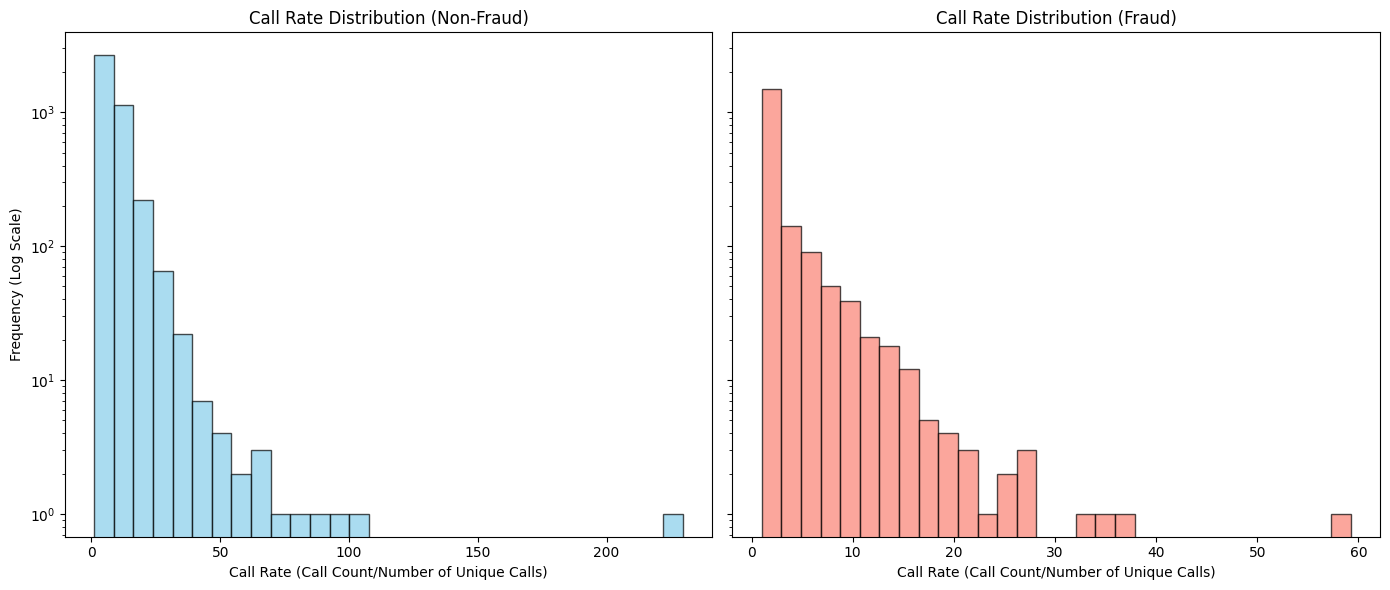

In [45]:
# Compute call rates
non_fraud_call_rate = non_fraud_data['call_count'] / non_fraud_data['call_unique']
fraud_call_rate = fraud_data['call_count'] / fraud_data['call_unique']

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_call_rate, bins=30, edgecolor='black', alpha=0.7, color='skyblue', log=True)
axes[0].set_title('Call Rate Distribution (Non-Fraud)')
axes[0].set_xlabel('Call Rate (Call Count/Number of Unique Calls)')
axes[0].set_ylabel('Frequency (Log Scale)')

# Plot histogram for fraud data
axes[1].hist(fraud_call_rate, bins=30, edgecolor='black', alpha=0.7, color='salmon', log=True)
axes[1].set_title('Call Rate Distribution (Fraud)')
axes[1].set_xlabel('Call Rate (Call Count/Number of Unique Calls)')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


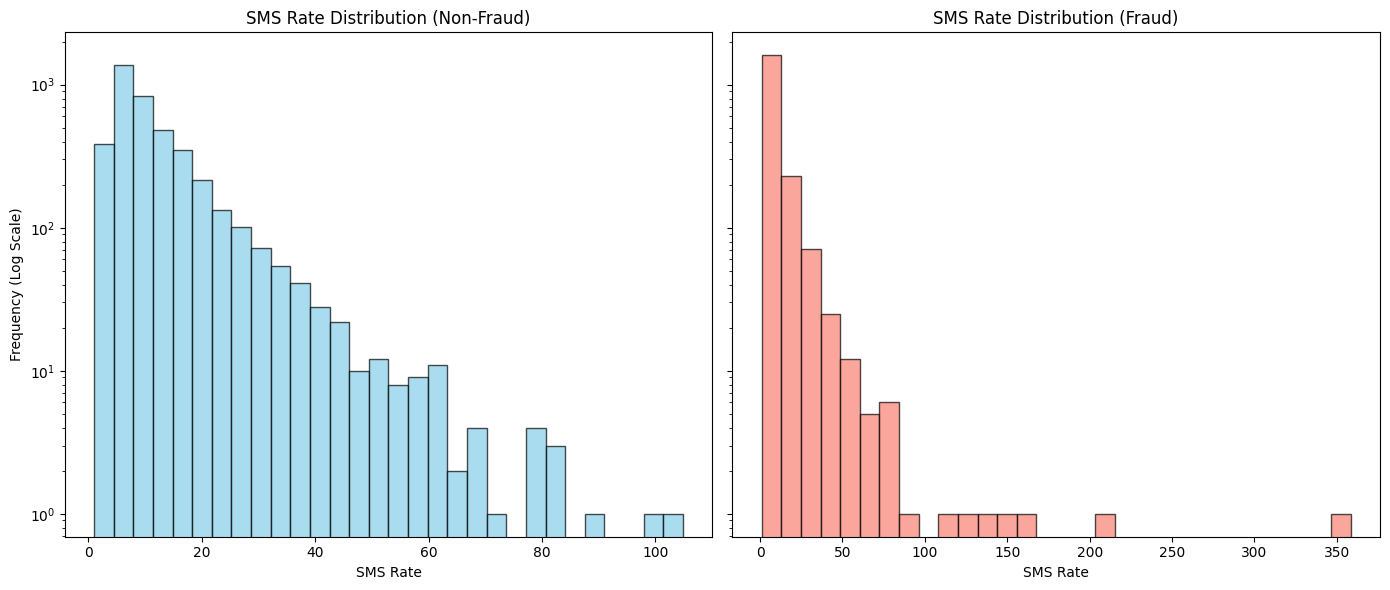

In [46]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot histogram for non-fraud data
axes[0].hist(non_fraud_data['sms_rate'], bins=30, edgecolor='black', alpha=0.7, color='skyblue', log=True)
axes[0].set_title('SMS Rate Distribution (Non-Fraud)')
axes[0].set_xlabel('SMS Rate')
axes[0].set_ylabel('Frequency (Log Scale)')

# Plot histogram for fraud data
axes[1].hist(fraud_data['sms_rate'], bins=30, edgecolor='black', alpha=0.7, color='salmon', log=True)
axes[1].set_title('SMS Rate Distribution (Fraud)')
axes[1].set_xlabel('SMS Rate')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


##### Box Plots

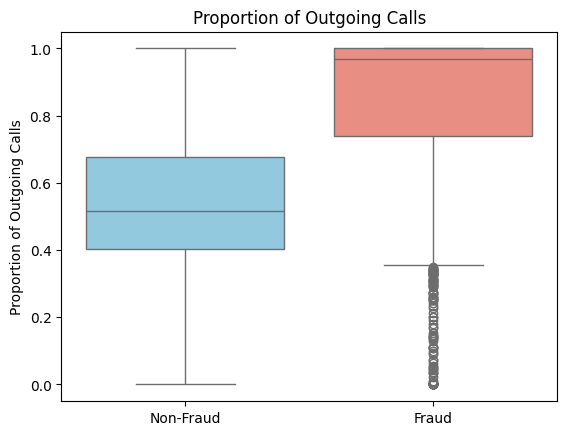

In [52]:
# Hypothesis: Fraudsters call more than they receive calls
sns.boxplot(x='label', y='voc_calltype1_proportion', data=df, hue='label', palette={0: 'skyblue', 1: 'salmon'})
plt.title('Proportion of Outgoing Calls')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('')
plt.ylabel('Proportion of Outgoing Calls')
plt.legend().remove()
plt.show()

Fraudulent users exhibit a strong preference for outgoing calls, with a median proportion close to 100%. In most cases, over 90% of their calls are outgoing.

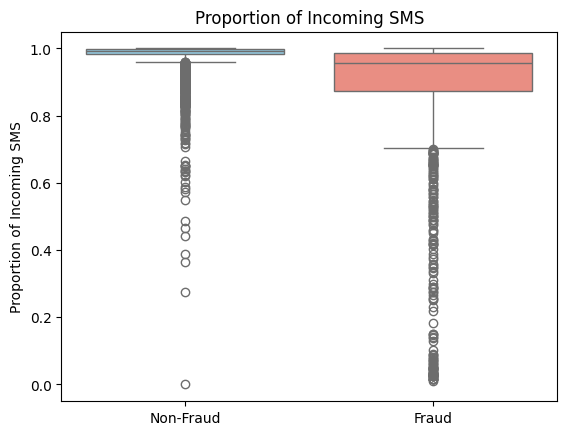

In [53]:
# Hypothesis: Fraudsters send more sms than they receive
sns.boxplot(x='label', y='sms_calltype2_proportion', data=df, hue='label', palette={0: 'skyblue', 1: 'salmon'})
plt.title('Proportion of Incoming SMS')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('')
plt.ylabel('Proportion of Incoming SMS')
plt.legend().remove()
plt.show()

Not true

In [43]:
# Fraudsters might call more unique contacts?
summary = df[['call_unique', 'label']].groupby('label').describe()
summary.index = summary.index.map({0: 'Non-Fraud', 1: 'Fraud'})
summary

summary = {
    'label': ['Non-Fraud', 'Fraud'],
    'count': [4133.0, 1892.0],
    'mean': [114.554319, 455.422304],
    'std': [187.688450, 1252.626616],
    'min': [1.0, 1.0],
    '25%': [27.0, 56.0],
    '50%': [61.0, 138.0],
    '75%': [137.0, 307.25],
    'max': [3731.0, 13746.0]
}

df_summary = pd.DataFrame(summary)
df_summary

,label,count,mean,std,min,25%,50%,75%,max
0,Non-Fraud,4133.0,114.554319,187.688450,1.0,27.0,61.0,137.00,3731.0
1,Fraud,1892.0,455.422304,1252.626616,1.0,56.0,138.0,307.25,13746.0


True, much higher mean of unique contacts contacted by fraudsters

In [44]:
# Fraudsters might sms more unique contacts?
summary = df[['sms_nunique_contact', 'label']].groupby('label').describe()
summary.index = summary.index.map({0: 'Non-Fraud', 1: 'Fraud'})
summary

summary = {
    'label': ['Non-Fraud', 'Fraud'],
    'count': [4141.0, 1962.0],
    'mean': [166.313209, 344.338430],
    'std': [208.173929, 1453.253247],
    'min': [1.0, 1.0],
    '25%': [36.0, 8.0],
    '50%': [92.0, 18.0],
    '75%': [226.0, 128.0],
    'max': [5808.0, 20931.0]
}

df_summary = pd.DataFrame(summary)
df_summary

,label,count,mean,std,min,25%,50%,75%,max
0,Non-Fraud,4141.0,166.313209,208.173929,1.0,36.0,92.0,226.0,5808.0
1,Fraud,1962.0,344.338430,1453.253247,1.0,8.0,18.0,128.0,20931.0


only true for some fraudsters

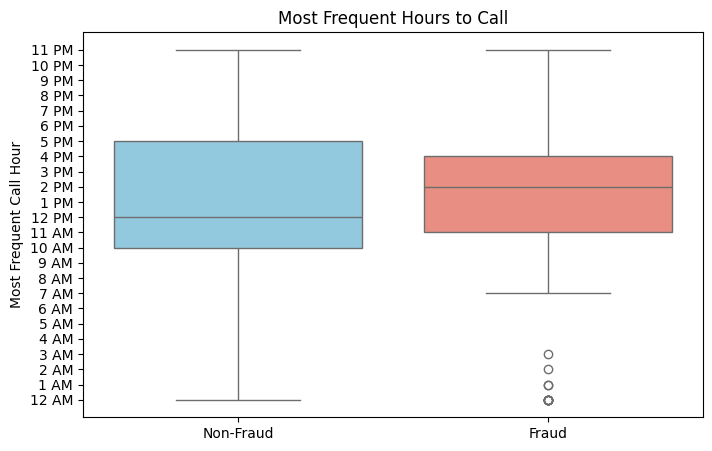

In [55]:
# Analyze the timings that fraudsters operate
plt.figure(figsize=(8,5)) 

sns.boxplot(x='label', y='voc_hour_mode', data=df, hue='label', palette={0: 'skyblue', 1: 'salmon'})
plt.yticks(
    ticks=range(24), 
    labels=[
        '12 AM', '1 AM', '2 AM', '3 AM', '4 AM', '5 AM', '6 AM', '7 AM', '8 AM', '9 AM',
        '10 AM', '11 AM', '12 PM', '1 PM', '2 PM', '3 PM', '4 PM', '5 PM',
        '6 PM', '7 PM', '8 PM', '9 PM', '10 PM', '11 PM'
    ]
)
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.title('Most Frequent Hours to Call')
plt.xlabel('')
plt.ylabel('Most Frequent Call Hour')
plt.legend().remove()
plt.show()


Legitimate users exhibit a broader range of frequent call times, typically spanning from 9 AM to 5 PM.

In contrast, fraudulent users demonstrate a more concentrated pattern, with their most frequent call times generally falling between 10 AM and 4 PM. This suggests a more consistent and focused timing in their call behavior.

/Users/britneysaw/Desktop/Y4S2/DSA4263/Final Project/dsa4263-project/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


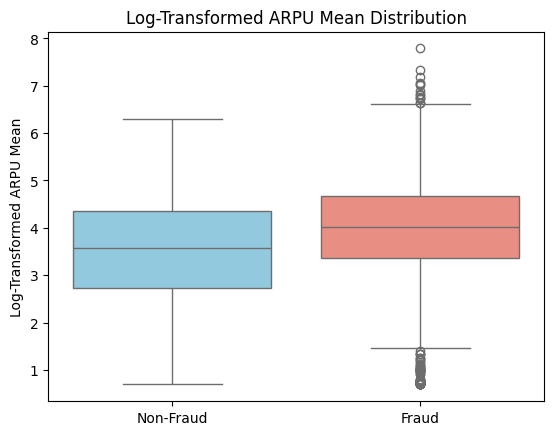

In [57]:
## Are fraudsters using more or less ARPU than legitimate users?
# Apply log transformation to arpu_mean (add a small constant to avoid log(0))
df['log_arpu_mean'] = np.log1p(df['arpu_mean'])

# Plot distribution for log-transformed arpu_mean
sns.boxplot(x='label', y='log_arpu_mean', data=df, hue='label', palette={0: 'skyblue', 1: 'salmon'})
plt.title('Log-Transformed ARPU Mean Distribution')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('')
plt.ylabel('Log-Transformed ARPU Mean')
plt.legend().remove()
plt.show()

More, but not significant

#### Graph Creation: Analyze relationship between Phone Numbers and IMEI

Create a graph where nodes are phone numbers, and edges connects subscribers if the same imei device was used

In [ ]:
# Prepare dataset
df_cleaned = df[["phone_no_m", "imei_list", "label"]] # Subset columns
df_cleaned = df_cleaned.dropna(subset=['imei_list']) # Remove rows with missing values in 'imei_list'

# Explode the imei_list so that each IMEI-phone number pair is a separate row
from ast import literal_eval
df_cleaned.loc[:, 'imei_list'] = df_cleaned['imei_list'].apply(literal_eval)  # convert to list type
df_exploded = df_cleaned.explode('imei_list')  # each row now represents one phone number-IMEI pair

# Create a mapping from IMEI to phone numbers
imei_to_numbers = df_exploded.groupby('imei_list')['phone_no_m'].apply(list).to_dict()

# Create graph
g = nx.Graph()
all_nodes = df_cleaned['phone_no_m'].unique()
g.add_nodes_from(all_nodes) # add all phone_no_m values as nodes to the graph

# Add edges between phone numbers that share the same IMEI
for imei, numbers in imei_to_numbers.items():
    # Create edges between all pairs of numbers sharing the same IMEI
    for i in range(len(numbers)):
        for j in range(i + 1, len(numbers)):
            phone_no_1 = numbers[i]
            phone_no_2 = numbers[j]

            if g.has_edge(phone_no_1, phone_no_2):
                g[phone_no_1][phone_no_2]['imei_count'] += 1 # add imei_count if edge exists
            else:
                g.add_edge(phone_no_1, phone_no_2, imei_count=1) # create new edge if edge doesn't exist

# Add fraud labels to nodes
node_labels = df_cleaned.set_index('phone_no_m')['label'].to_dict()
nx.set_node_attributes(g, node_labels, 'fraud_label')

# Map fraud label to colors
color_map = {0: 'green', 1: 'red'} # assign green to non-fraud, red to fraud
node_color = [color_map[g.nodes[node]['fraud_label']] for node in g.nodes()]

# Note: should have 4133 non fraud, 1892 fraud nodes

The graph may contain multiple connected components, where each component represents a group of phone numbers sharing IMEI devices. 

Hypothesis: Larger components indicate phone numbers used on the same device, indicating fraud.

In [38]:
connected_components = list(nx.connected_components(g))
print(f"Number of connected components: {len(connected_components)}")

component_sizes = [len(component) for component in connected_components]
print(f"Largest component size: {max(component_sizes)}")
print(f"Smallest component size: {min(component_sizes)}")

for i, component in enumerate(connected_components):
    print(f"Component {i+1}: {len(component)} nodes")

Number of connected components: 5361
Largest component size: 335
Smallest component size: 1
Component 1: 1 nodes
Component 2: 1 nodes
Component 3: 1 nodes
Component 4: 1 nodes
Component 5: 1 nodes
Component 6: 1 nodes
Component 7: 1 nodes
Component 8: 1 nodes
Component 9: 2 nodes
Component 10: 1 nodes
Component 11: 1 nodes
Component 12: 1 nodes
Component 13: 1 nodes
Component 14: 1 nodes
Component 15: 1 nodes
Component 16: 1 nodes
Component 17: 1 nodes
Component 18: 1 nodes
Component 19: 1 nodes
Component 20: 1 nodes
Component 21: 4 nodes
Component 22: 335 nodes
Component 23: 1 nodes
Component 24: 1 nodes
Component 25: 1 nodes
Component 26: 1 nodes
Component 27: 1 nodes
Component 28: 1 nodes
Component 29: 1 nodes
Component 30: 3 nodes
Component 31: 1 nodes
Component 32: 1 nodes
Component 33: 1 nodes
Component 34: 1 nodes
Component 35: 1 nodes
Component 36: 1 nodes
Component 37: 1 nodes
Component 38: 1 nodes
Component 39: 1 nodes
Component 40: 1 nodes
Component 41: 1 nodes
Component 42:

What percentage of nodes in each component size are fraudulent?

This code groups components by their size, counts the total number of nodes and fraudulent nodes in each group, and calculates the percentage of fraudulent nodes in each group.

In [ ]:
# Create a dictionary to store component sizes and their fraud status
component_stats = defaultdict(lambda: {"total_nodes": 0, "fraud_nodes": 0})

for component in connected_components:
    size = len(component)
    fraud_count = sum(1 for node in component if g.nodes[node]['fraud_label'] == 1)
    component_stats[size]["total_nodes"] += size
    component_stats[size]["fraud_nodes"] += fraud_count

sorted_component_stats = sorted(component_stats.items(), key=lambda x: x[0])

# Print the results
for size, stats in sorted_component_stats:
    print(f"Components of size {size}:")
    print(f"  Total nodes: {stats['total_nodes']}")
    print(f"  Fraudulent nodes: {stats['fraud_nodes']}")
    print(f"  Percentage fraudulent: {stats['fraud_nodes'] / stats['total_nodes'] * 100:.2f}%")

Components of size 1:
  Total nodes: 5246
  Fraudulent nodes: 1139
  Percentage fraudulent: 21.71%
Components of size 2:
  Total nodes: 138
  Fraudulent nodes: 127
  Percentage fraudulent: 92.03%
Components of size 3:
  Total nodes: 51
  Fraudulent nodes: 50
  Percentage fraudulent: 98.04%
Components of size 4:
  Total nodes: 48
  Fraudulent nodes: 45
  Percentage fraudulent: 93.75%
Components of size 5:
  Total nodes: 15
  Fraudulent nodes: 15
  Percentage fraudulent: 100.00%
Components of size 6:
  Total nodes: 12
  Fraudulent nodes: 12
  Percentage fraudulent: 100.00%
Components of size 7:
  Total nodes: 14
  Fraudulent nodes: 13
  Percentage fraudulent: 92.86%
Components of size 8:
  Total nodes: 8
  Fraudulent nodes: 8
  Percentage fraudulent: 100.00%
Components of size 9:
  Total nodes: 9
  Fraudulent nodes: 0
  Percentage fraudulent: 0.00%
Components of size 11:
  Total nodes: 11
  Fraudulent nodes: 11
  Percentage fraudulent: 100.00%
Components of size 15:
  Total nodes: 15
  F

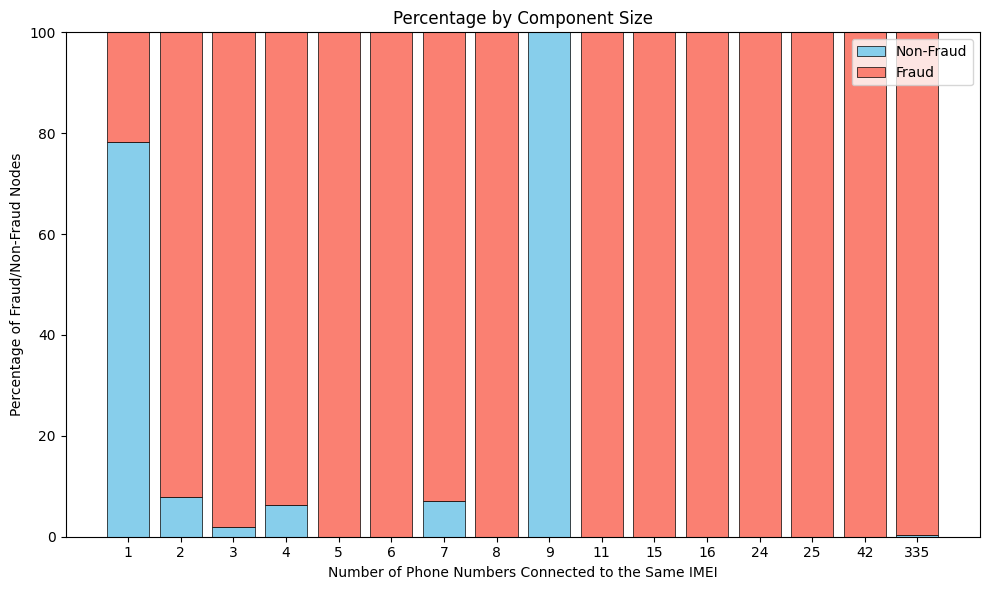

In [68]:
x = []
y_fraud = []
y_nonfraud = []

for size, stats in sorted_component_stats:
    total = stats['total_nodes']
    fraud = stats['fraud_nodes']
    fraud_percent = (fraud / total) * 100
    nonfraud_percent = 100 - fraud_percent

    x.append(size)
    y_fraud.append(fraud_percent)
    y_nonfraud.append(nonfraud_percent)


x_pos = list(range(len(x)))

plt.figure(figsize=(10, 6))
plt.bar(
    x_pos, 
    y_nonfraud, 
    label='Non-Fraud', 
    color='skyblue', 
    edgecolor='black', 
    linewidth=0.5
)
plt.bar(
    x_pos, 
    y_fraud, 
    bottom=y_nonfraud, 
    label='Fraud', 
    color='salmon', 
    edgecolor='black', 
    linewidth=0.5
)

plt.xticks(x_pos, x)
plt.xlabel("Number of Phone Numbers Connected to the Same IMEI")
plt.ylabel("Percentage of Fraud/Non-Fraud Nodes")
plt.title("Percentage by Component Size")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()